# 🍷 WINE QUALITY PREDICTION - COMPREHENSIVE ML & VISUALIZATION

## Dataset: Wine Quality Dataset
**Kaynak:** https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

## 🎯 Proje Hedefi: SARAP KALITE TAHMINI (MULTI-APPROACH)

## 🌟 Proje Ozellikleri:
- **Multi-Approach:** Hem Regression hem Classification
- **Wine-Specific Analysis:** Chemical property insights
- **Red vs White Comparison:** Type-based analysis
- **20+ Detayli Gorsellestirme**
- **15+ ML Model** (Regression + Classification)
- **7-Part Visual Comparison**
- **Domain Expert Insights**

## 📋 Proje Adimlari:
1. Veri Yukleme & Ilk Analiz
2. **DETAYLI EDA** (Wine-specific + 20+ grafik)
3. Feature Engineering (Chemical interactions)
4. **REGRESSION MODELS** (Quality score prediction)
5. **CLASSIFICATION MODELS** (Quality categories)
6. **KAPSAMLI KARSILASTIRMA** (7-Part visual + table)
7. Wine Expert Insights & Recommendations

## 1️⃣ KUTUPHANE YUKLEME

In [3]:
# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE

# CatBoost'u yukle
!pip install catboost

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrikler - Regression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)

# Metrikler - Classification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# Plotly
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY = True
except:
    PLOTLY = False

# Viz
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('='*80)
print('🍷 WINE QUALITY ANALYSIS - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Plotly: {"Available" if PLOTLY else "Not Available"}')
print('='*80)

🍷 WINE QUALITY ANALYSIS - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Plotly: Available


## 2️⃣ VERI YUKLEME

In [4]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"\n{'='*80}")
    print(f"🍷 INDIRILIYOR: {zip_filename}")
    print(f"{'='*80}")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [5]:
# Dataset indirme
dataset_folder = "wine_quality_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/yasserh/wine-quality-dataset",
    "folder": dataset_folder,
    "zip_filename": "wine-quality.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("✅ Dataset zaten mevcut!")


🍷 INDIRILIYOR: wine-quality.zip


In [6]:
# Veri yukleme
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    # Dosya secimi
    print(f'\n📁 Bulunan CSV dosyalari:')
    for i, f in enumerate(csv_files):
        print(f'  {i+1}. {os.path.basename(f)}')

    df = pd.read_csv(csv_files[0])

    print('\n' + '='*80)
    print('✅ VERI YUKLENDI!')
    print('='*80)
    print(f'📊 Toplam Kayit: {len(df):,}')
    print(f'📊 Sutun Sayisi: {len(df.columns)}')
    print(f'💾 Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('❌ CSV dosyasi bulunamadi!')


📁 Bulunan CSV dosyalari:
  1. WineQT.csv

✅ VERI YUKLENDI!
📊 Toplam Kayit: 1,143
📊 Sutun Sayisi: 13
💾 Bellek: 0.11 MB


In [7]:
# Ilk bakis
print('\n🍷 ILK 10 KAYIT:')
df.head(10)


🍷 ILK 10 KAYIT:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,0
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5,1
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5,2
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6,3
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,4
5,7.4000,0.6600,0.0000,1.8000,0.0750,13.0000,40.0000,0.9978,3.5100,0.5600,9.4000,5,5
6,7.9000,0.6000,0.0600,1.6000,0.0690,15.0000,59.0000,0.9964,3.3000,0.4600,9.4000,5,6
7,7.3000,0.6500,0.0000,1.2000,0.0650,15.0000,21.0000,0.9946,3.3900,0.4700,10.0000,7,7
8,7.8000,0.5800,0.0200,2.0000,0.0730,9.0000,18.0000,0.9968,3.3600,0.5700,9.5000,7,8
9,6.7000,0.5800,0.0800,1.8000,0.0970,15.0000,65.0000,0.9959,3.2800,0.5400,9.2000,5,10


In [8]:
# Veri yapisi
print('\n📊 VERI YAPISI:')
print('='*80)
df.info()


📊 VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [9]:
# Istatistiksel ozet
print('\n📈 ISTATISTIKSEL OZET:')
print('='*80)
df.describe().T


📈 ISTATISTIKSEL OZET:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0000,8.3111,1.7476,4.6000,7.1000,7.9000,9.1000,15.9000
volatile acidity,1143.0000,0.5313,0.1796,0.1200,0.3925,0.5200,0.6400,1.5800
citric acid,1143.0000,0.2684,0.1967,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,1143.0000,2.5322,1.3559,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1143.0000,0.0869,0.0473,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1143.0000,15.6155,10.2505,1.0000,7.0000,13.0000,21.0000,68.0000
total sulfur dioxide,1143.0000,45.9147,32.7821,6.0000,21.0000,37.0000,61.0000,289.0000
density,1143.0000,0.9967,0.0019,0.9901,0.9956,0.9967,0.9978,1.0037
pH,1143.0000,3.3110,0.1567,2.7400,3.2050,3.3100,3.4000,4.0100
sulphates,1143.0000,0.6577,0.1704,0.3300,0.5500,0.6200,0.7300,2.0000


## 3️⃣ DETAYLI EDA - WINE-SPECIFIC ANALYSIS

### 🍷 Quality Distribution Analysis

In [10]:
# Quality sutununu bul
quality_col = 'quality' if 'quality' in df.columns else df.columns[-1]

print('='*80)
print(f'🎯 QUALITY COLUMN: {quality_col}')
print('='*80)
print('\n📊 Quality Dagilimi:')
print(df[quality_col].value_counts().sort_index())
print('\n📊 Istatistikler:')
print(f'Ortalama: {df[quality_col].mean():.2f}')
print(f'Medyan: {df[quality_col].median():.2f}')
print(f'Std: {df[quality_col].std():.2f}')
print(f'Min: {df[quality_col].min():.0f}')
print(f'Max: {df[quality_col].max():.0f}')

🎯 QUALITY COLUMN: quality

📊 Quality Dagilimi:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

📊 Istatistikler:
Ortalama: 5.66
Medyan: 6.00
Std: 0.81
Min: 3
Max: 8


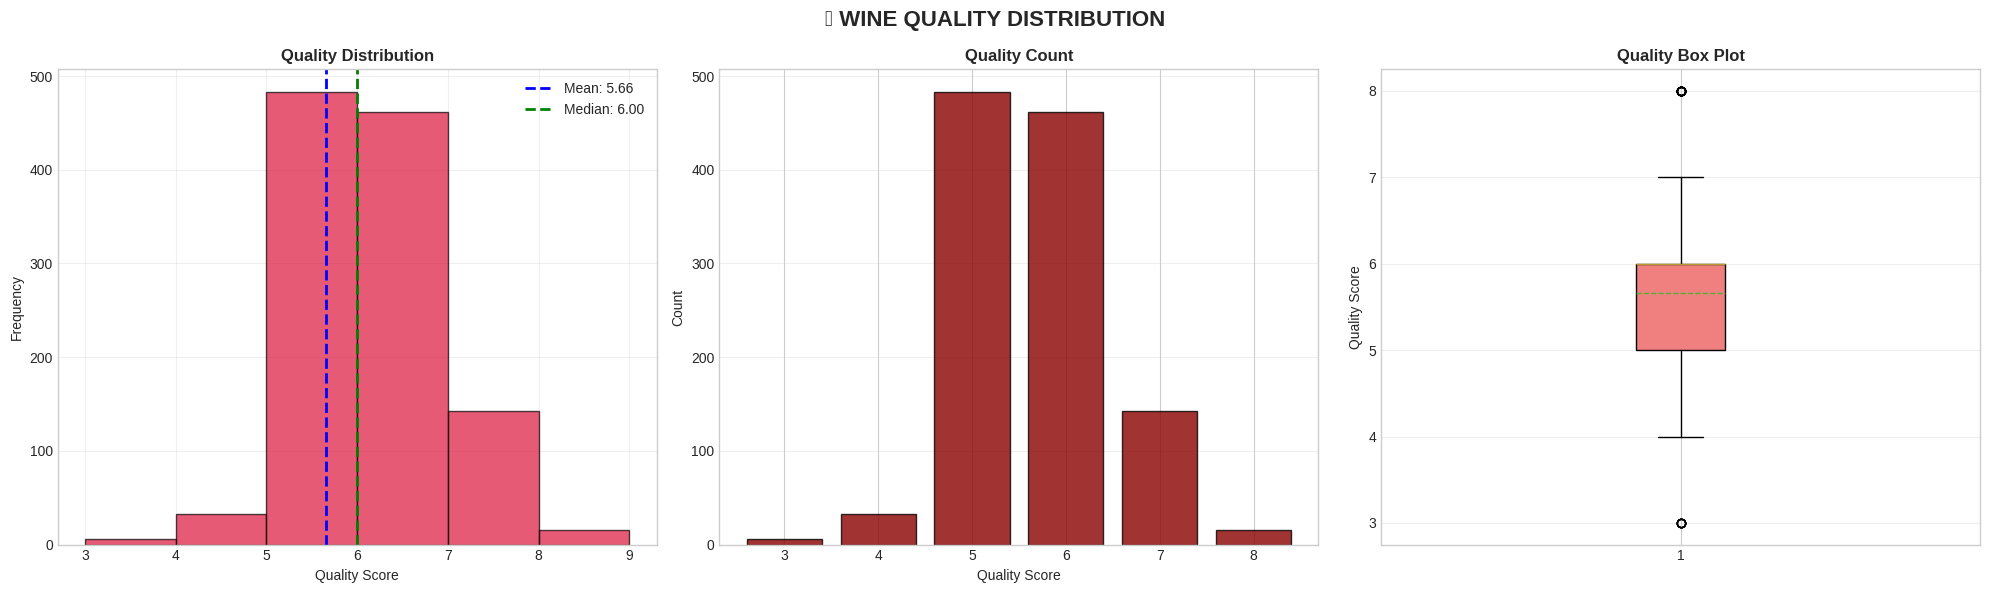

In [11]:
# Quality visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🍷 WINE QUALITY DISTRIBUTION', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(df[quality_col], bins=range(int(df[quality_col].min()),
                                         int(df[quality_col].max())+2),
            color='crimson', edgecolor='black', alpha=0.7)
axes[0].axvline(df[quality_col].mean(), color='blue', linestyle='--',
               linewidth=2, label=f'Mean: {df[quality_col].mean():.2f}')
axes[0].axvline(df[quality_col].median(), color='green', linestyle='--',
               linewidth=2, label=f'Median: {df[quality_col].median():.2f}')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Quality Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bar plot
quality_counts = df[quality_col].value_counts().sort_index()
axes[1].bar(quality_counts.index, quality_counts.values,
           color='darkred', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Quality Count', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Box plot
bp = axes[2].boxplot([df[quality_col]], patch_artist=True,
                     showmeans=True, meanline=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
axes[2].set_ylabel('Quality Score')
axes[2].set_title('Quality Box Plot', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 🍷 Wine Type Analysis (Red vs White)

In [12]:
# Wine type var mi kontrol
type_col = None
for col in df.columns:
    if 'type' in col.lower() or 'color' in col.lower():
        type_col = col
        break

if type_col:
    print(f'\n🍷 WINE TYPE: {type_col}')
    print('='*80)
    print(df[type_col].value_counts())

    # Type'a gore quality
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('🍷 QUALITY BY WINE TYPE', fontsize=16, fontweight='bold')

    # Box plot
    df.boxplot(column=quality_col, by=type_col, ax=axes[0],
              patch_artist=True)
    axes[0].set_title('Quality Distribution by Type')
    axes[0].set_xlabel('Wine Type')
    axes[0].set_ylabel('Quality')
    plt.suptitle('')

    # Violin plot
    for wine_type in df[type_col].unique():
        subset = df[df[type_col] == wine_type][quality_col]
        axes[1].violinplot([subset], positions=[list(df[type_col].unique()).index(wine_type)],
                          showmeans=True, showmedians=True)
    axes[1].set_xticks(range(len(df[type_col].unique())))
    axes[1].set_xticklabels(df[type_col].unique())
    axes[1].set_title('Quality Violin Plot by Type')
    axes[1].set_xlabel('Wine Type')
    axes[1].set_ylabel('Quality')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('\n⚠️ Wine type column bulunamadi')


⚠️ Wine type column bulunamadi


### 📊 Chemical Properties Analysis

In [13]:
# Numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if quality_col in numeric_cols:
    numeric_cols.remove(quality_col)

print(f'\n📊 CHEMICAL PROPERTIES ({len(numeric_cols)} features):')
for col in numeric_cols:
    print(f'  ✓ {col}')


📊 CHEMICAL PROPERTIES (12 features):
  ✓ fixed acidity
  ✓ volatile acidity
  ✓ citric acid
  ✓ residual sugar
  ✓ chlorides
  ✓ free sulfur dioxide
  ✓ total sulfur dioxide
  ✓ density
  ✓ pH
  ✓ sulphates
  ✓ alcohol
  ✓ Id


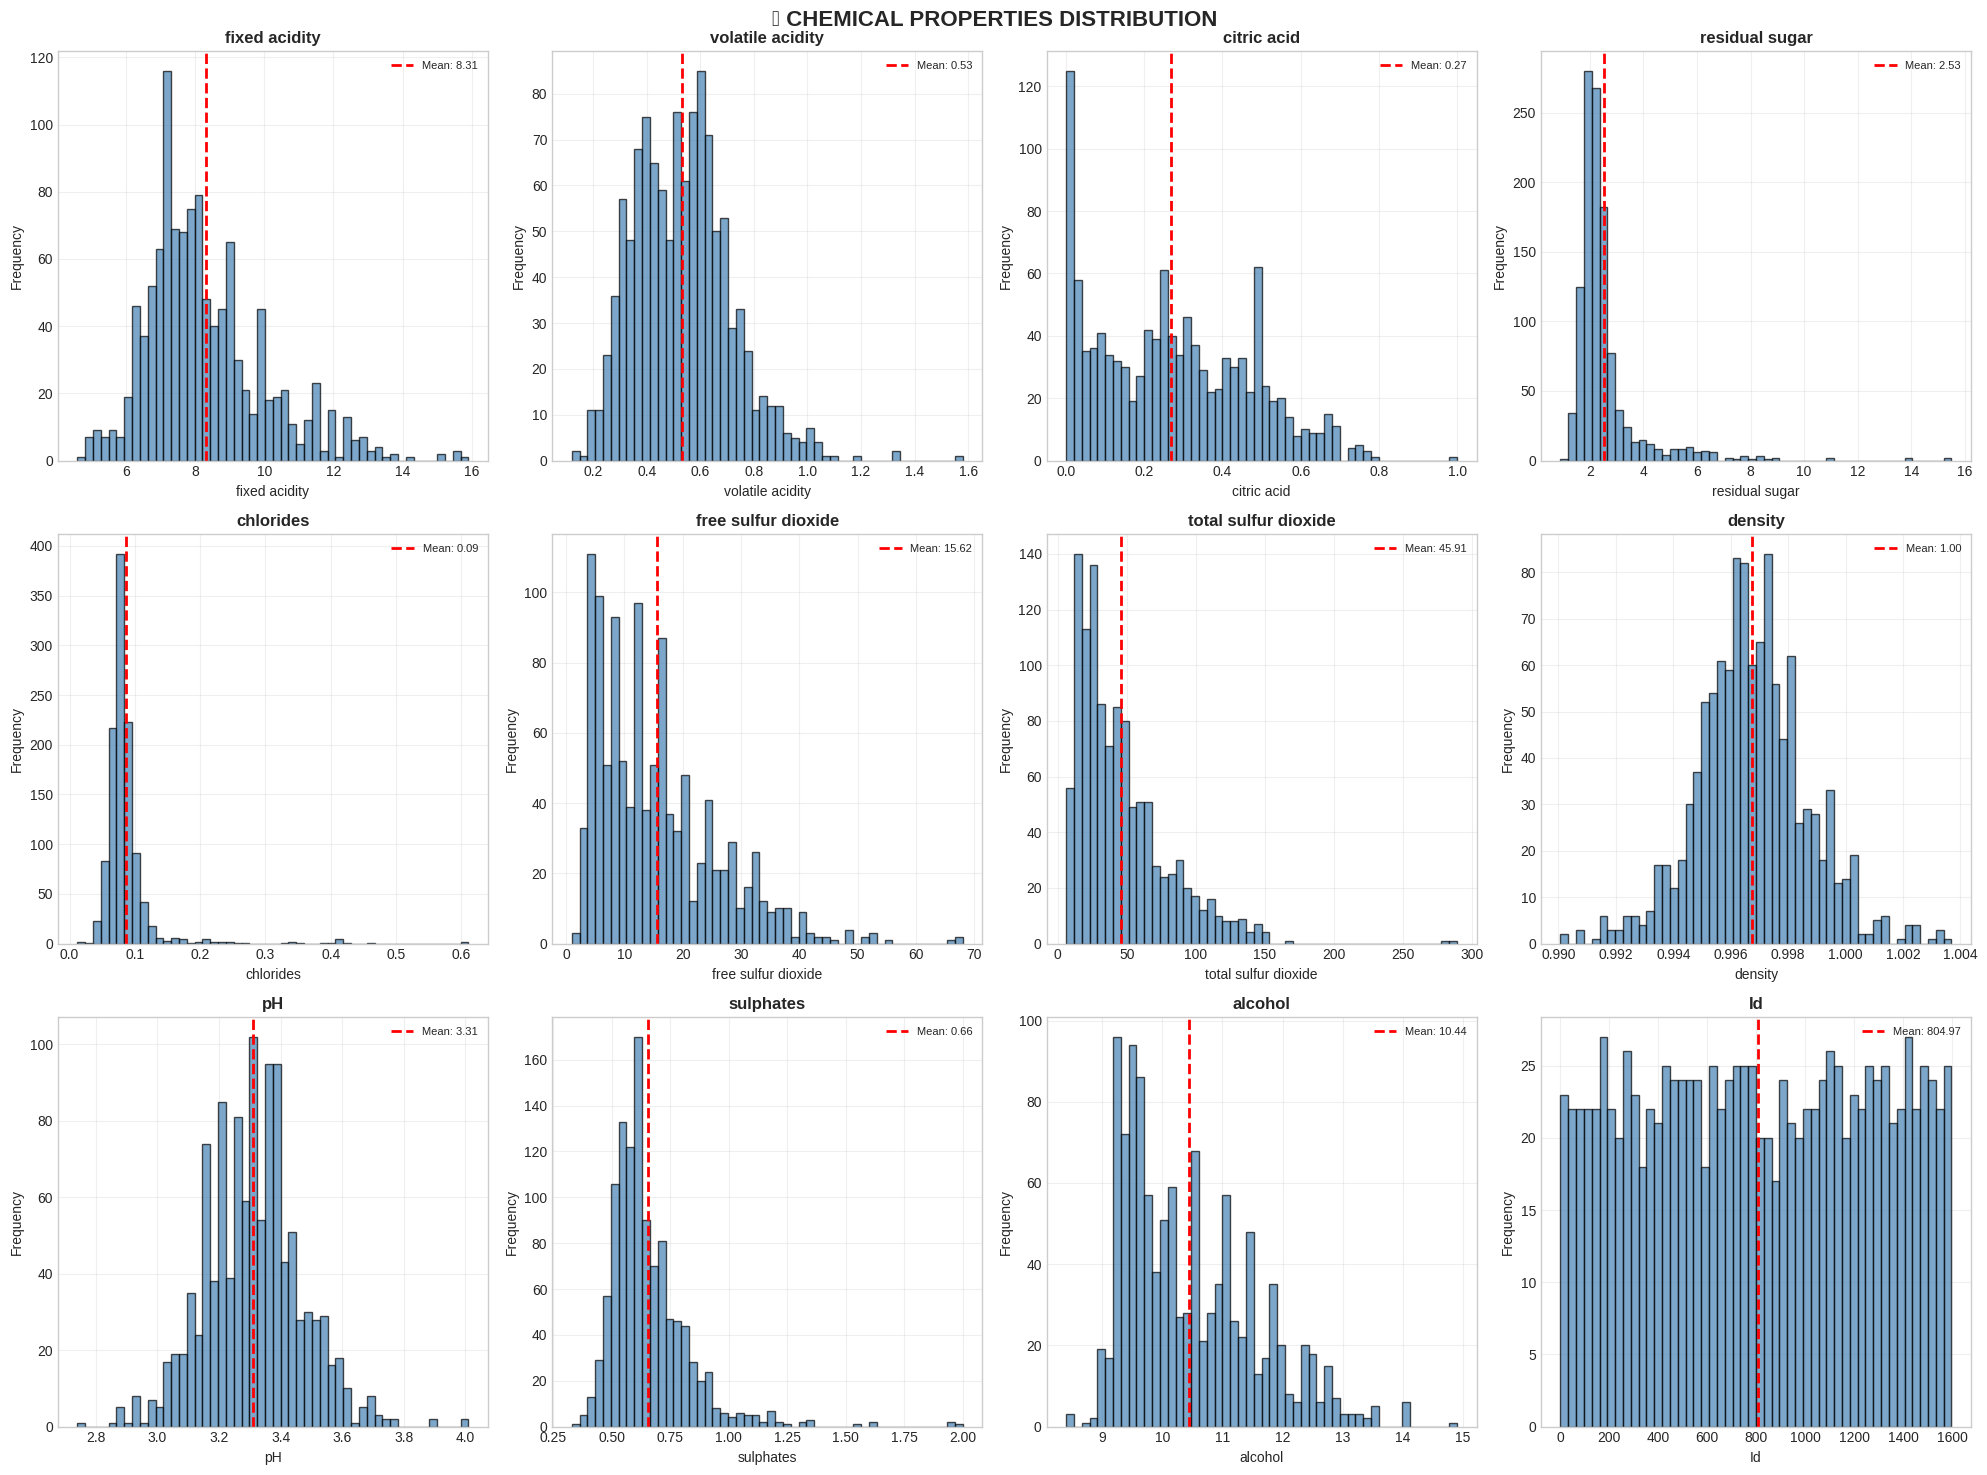

In [14]:
# Distribution plots - ALL features
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('📊 CHEMICAL PROPERTIES DISTRIBUTION', fontsize=16, fontweight='bold')
axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=50, color='steelblue',
                  edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--',
                     linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

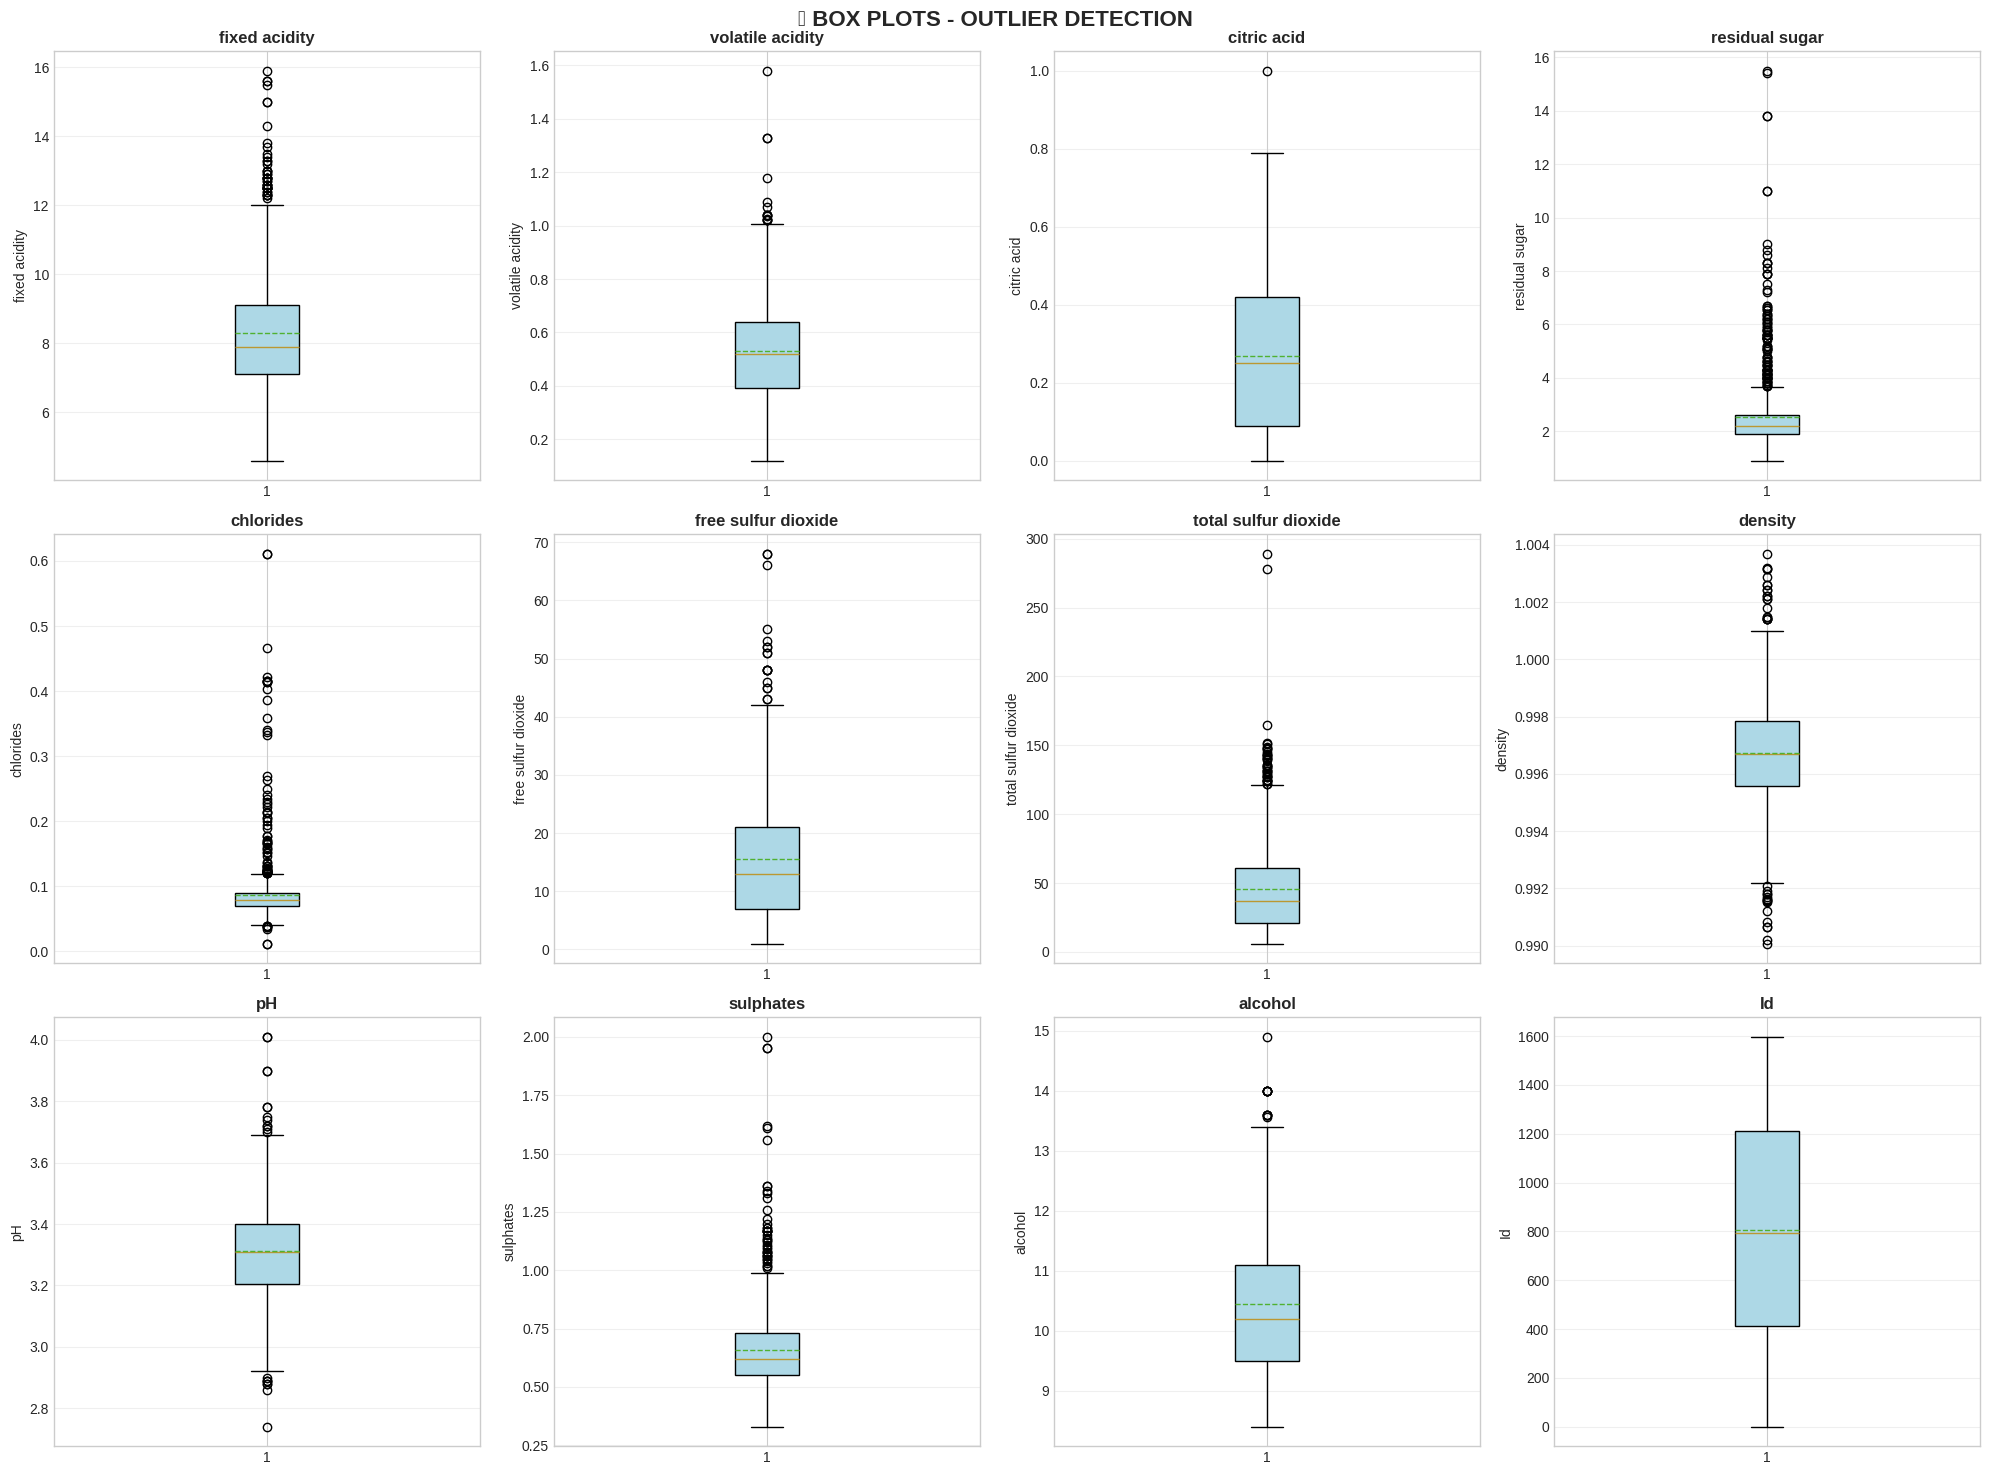

In [15]:
# Box plots - Outlier detection
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('📦 BOX PLOTS - OUTLIER DETECTION', fontsize=16, fontweight='bold')
axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    bp = axes[idx].boxplot([df[col].dropna()], patch_artist=True,
                           showmeans=True, meanline=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 🔗 Quality vs Chemical Properties

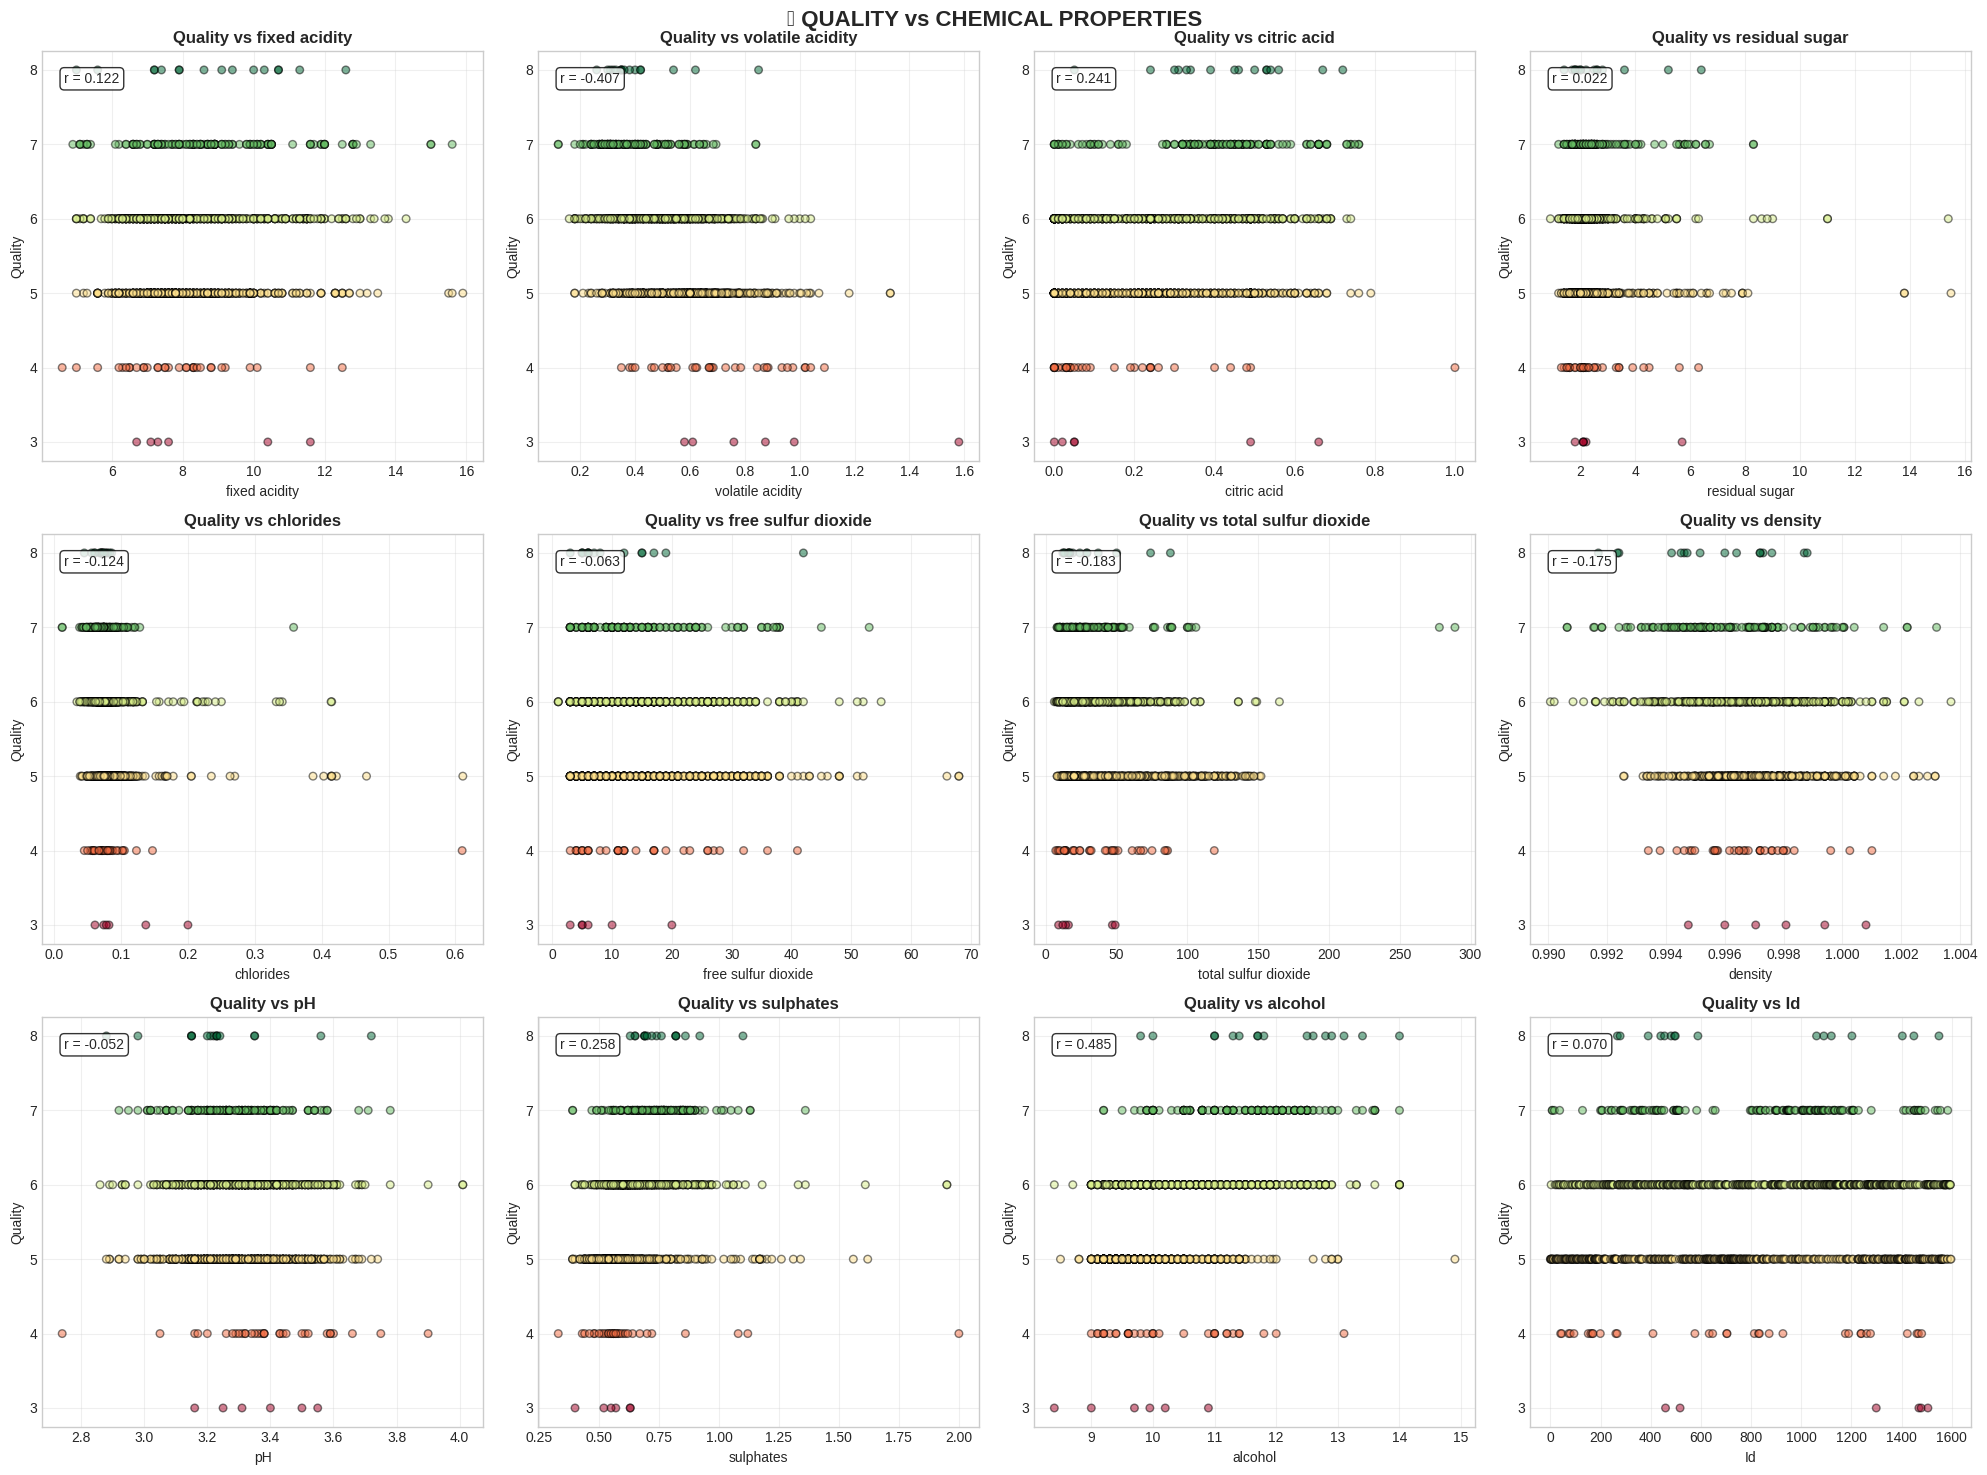

In [16]:
# Scatter plots - Quality vs each feature
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('🔗 QUALITY vs CHEMICAL PROPERTIES', fontsize=16, fontweight='bold')
axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].scatter(df[col], df[quality_col], alpha=0.5,
                     c=df[quality_col], cmap='RdYlGn',
                     edgecolor='black', s=30)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Quality')
    axes[idx].set_title(f'Quality vs {col}', fontweight='bold')
    axes[idx].grid(alpha=0.3)

    # Correlation
    corr = df[[col, quality_col]].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r = {corr:.3f}',
                  transform=axes[idx].transAxes,
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                  verticalalignment='top')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 🔗 Correlation Analysis

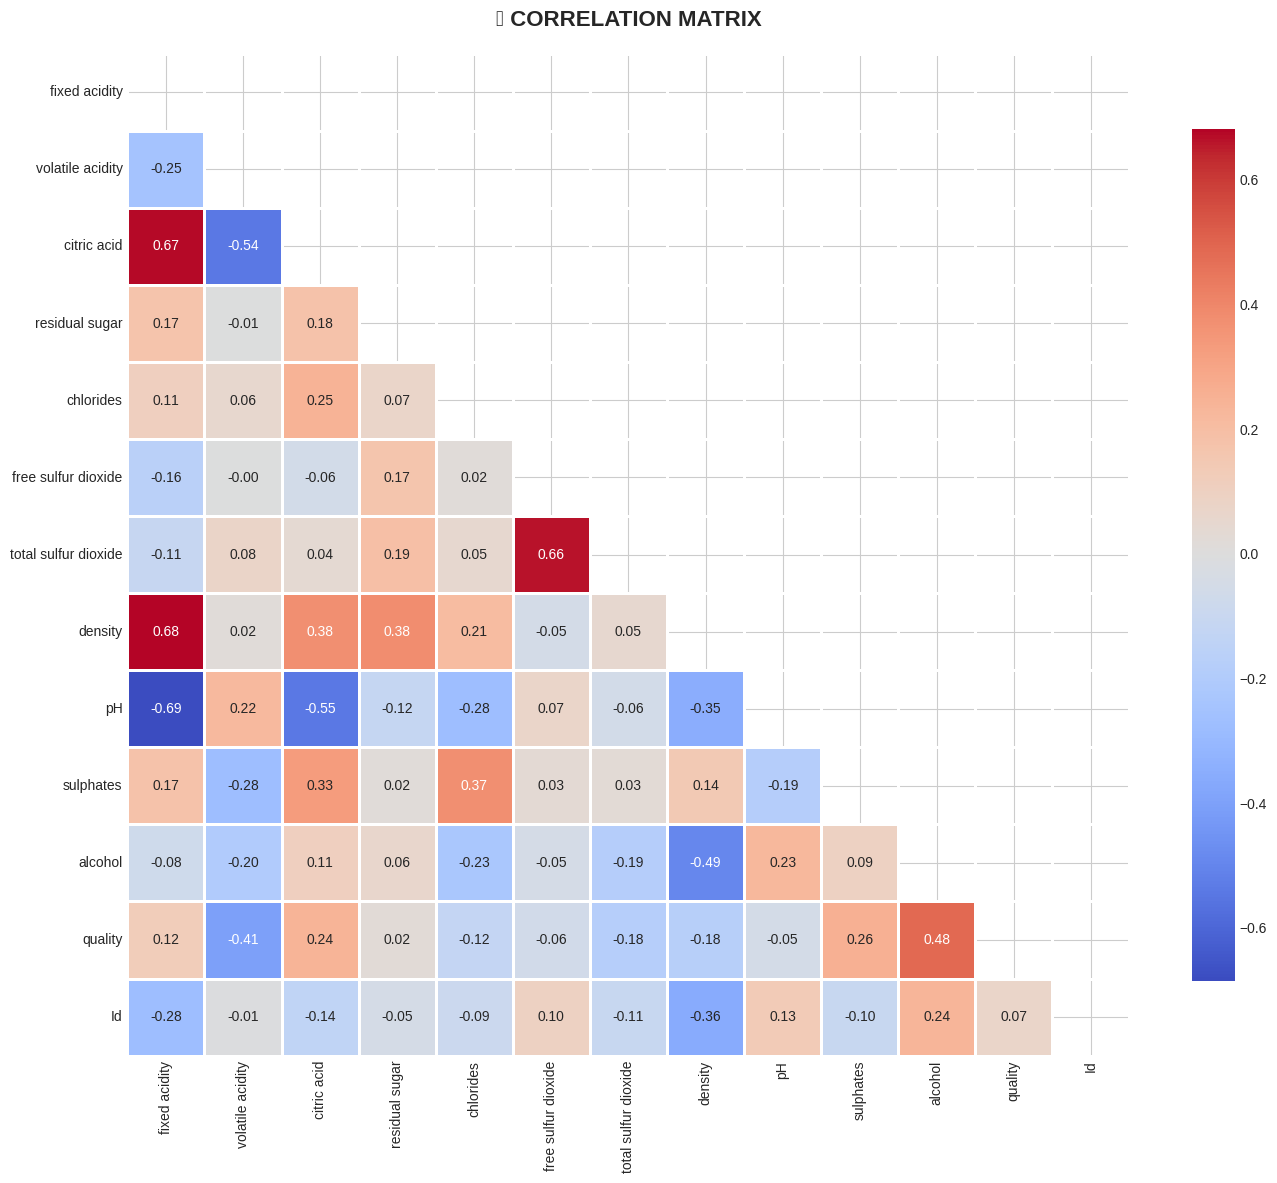


🎯 QUALITY KORELASYONLARI:
quality                1.0000
alcohol                0.4849
volatile acidity       0.4074
sulphates              0.2577
citric acid            0.2408
total sulfur dioxide   0.1833
density                0.1752
chlorides              0.1241
fixed acidity          0.1220
Id                     0.0697
free sulfur dioxide    0.0633
pH                     0.0525
residual sugar         0.0220
Name: quality, dtype: float64


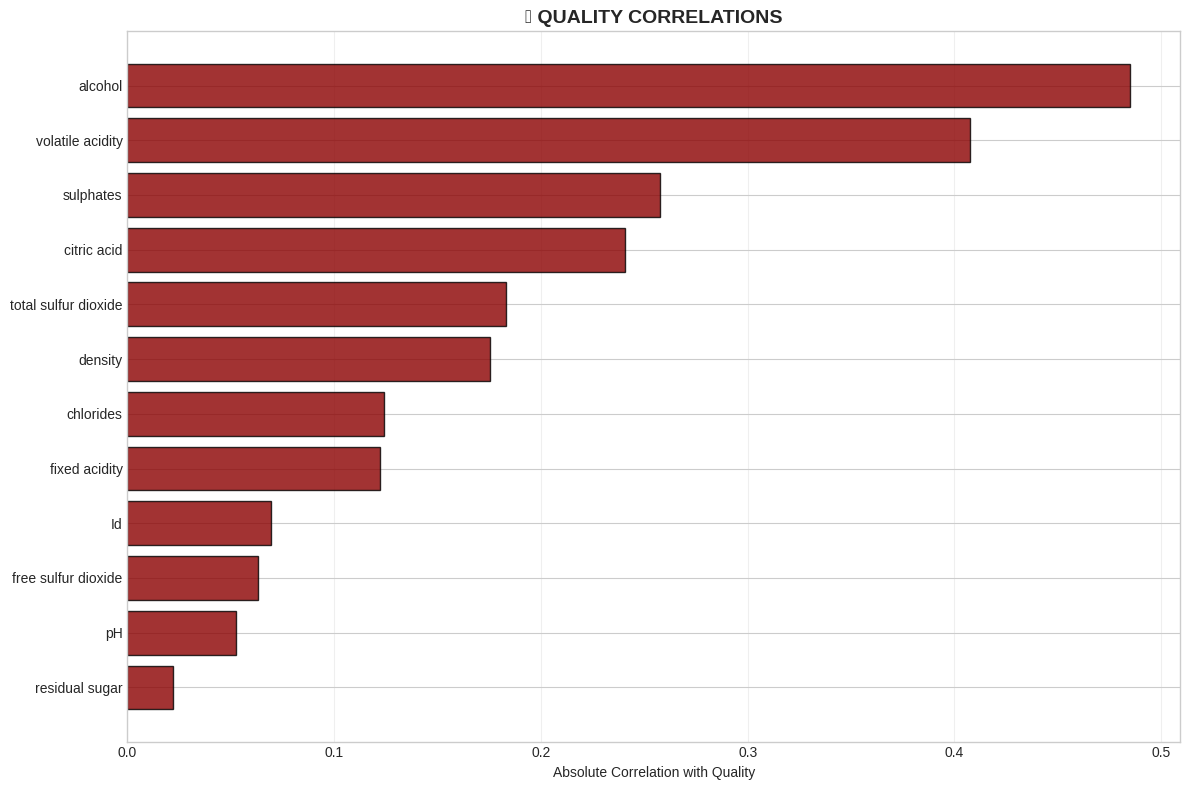

In [17]:
# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
           cmap='coolwarm', center=0, linewidths=1,
           cbar_kws={'shrink': 0.8}, square=True)
plt.title('🔗 CORRELATION MATRIX', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Quality korelasyonlari
if quality_col in corr.columns:
    quality_corr = corr[quality_col].abs().sort_values(ascending=False)
    print(f'\n🎯 QUALITY KORELASYONLARI:')
    print('='*80)
    print(quality_corr)

    # Gorsel
    plt.figure(figsize=(12, 8))
    quality_corr_plot = quality_corr[quality_corr.index != quality_col]
    plt.barh(range(len(quality_corr_plot)), quality_corr_plot.values,
            color='darkred', edgecolor='black', alpha=0.8)
    plt.yticks(range(len(quality_corr_plot)), quality_corr_plot.index)
    plt.xlabel('Absolute Correlation with Quality')
    plt.title('🎯 QUALITY CORRELATIONS', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 📊 Pair Plot (Top Features)


📊 PAIR PLOT - Top 4 features...


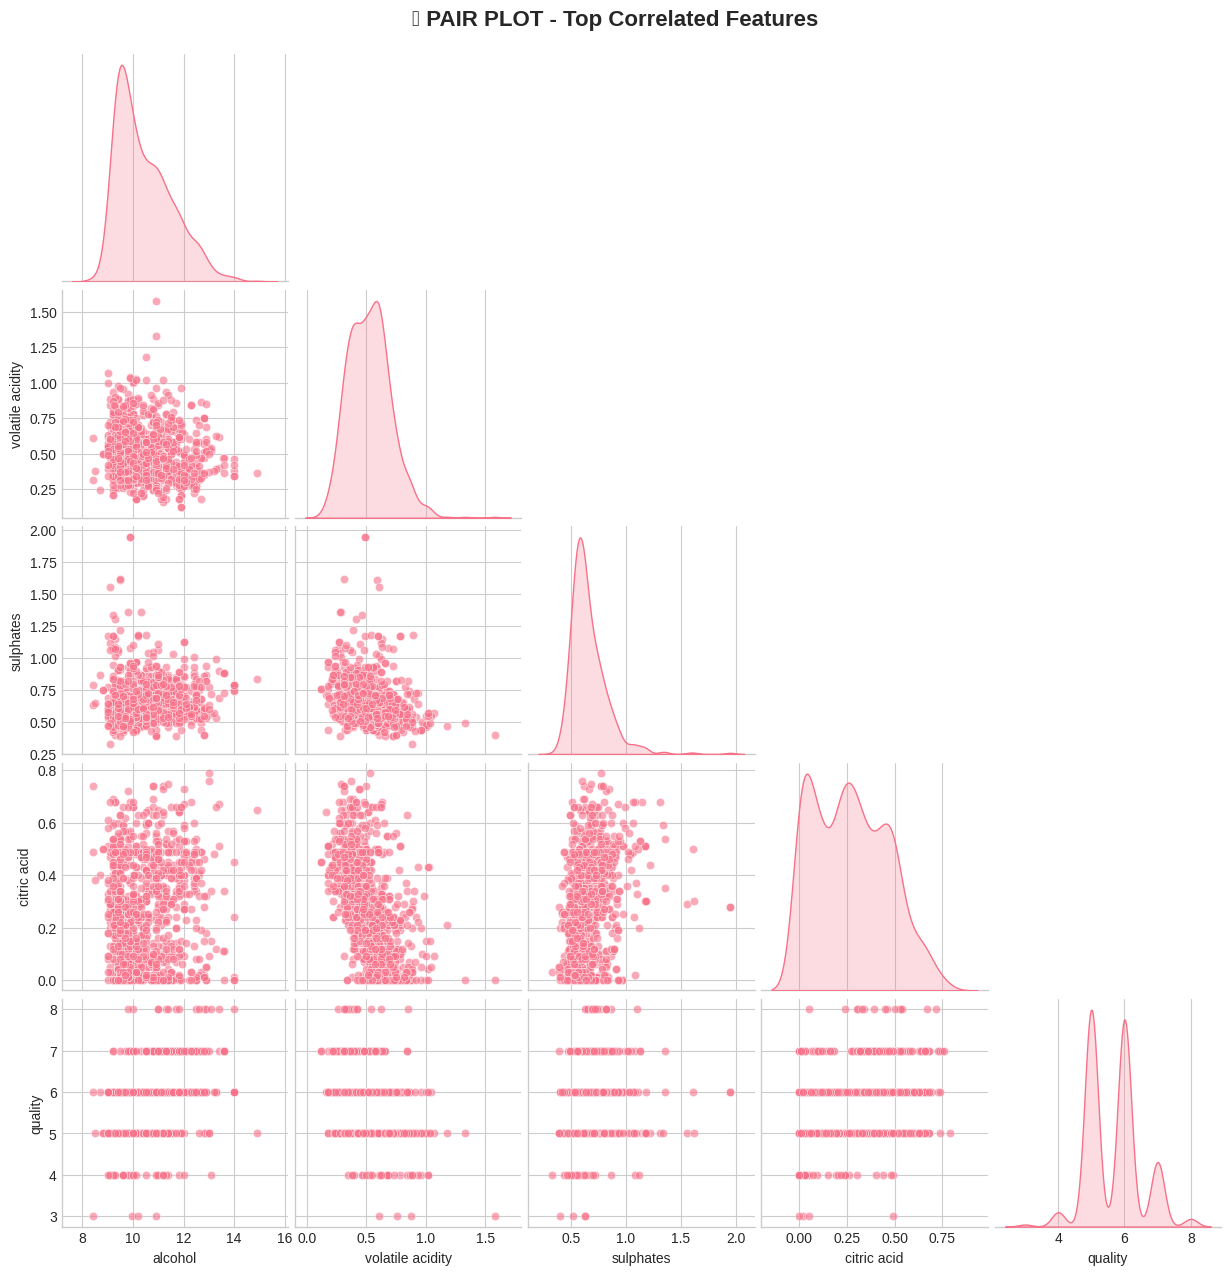

In [18]:
# Top correlated features pair plot
if quality_col in corr.columns:
    top_features = corr[quality_col].abs().sort_values(ascending=False)[1:5].index.tolist()
    top_features.append(quality_col)

    print(f'\n📊 PAIR PLOT - Top {len(top_features)-1} features...')
    pair_plot = sns.pairplot(df[top_features].sample(min(1000, len(df))),
                            diag_kind='kde', plot_kws={'alpha': 0.6},
                            corner=True)
    pair_plot.fig.suptitle('📊 PAIR PLOT - Top Correlated Features',
                          y=1.02, fontweight='bold', fontsize=16)
    plt.show()

## 4️⃣ FEATURE ENGINEERING

In [19]:
print('='*80)
print('🔧 FEATURE ENGINEERING - WINE SPECIFIC')
print('='*80)

df_clean = df.copy()

# 1. Acidity ratio
acid_cols = [c for c in df_clean.columns if 'acid' in c.lower()]
if len(acid_cols) >= 2:
    df_clean['acidity_ratio'] = df_clean[acid_cols[0]] / (df_clean[acid_cols[1]] + 1e-6)
    print('✅ acidity_ratio olusturuldu')

# 2. Sulfur ratio
sulfur_cols = [c for c in df_clean.columns if 'sulfur' in c.lower()]
if len(sulfur_cols) >= 2:
    df_clean['sulfur_ratio'] = df_clean[sulfur_cols[0]] / (df_clean[sulfur_cols[1]] + 1e-6)
    print('✅ sulfur_ratio olusturuldu')

# 3. Alcohol categories
if 'alcohol' in [c.lower() for c in df_clean.columns]:
    alc_col = [c for c in df_clean.columns if c.lower() == 'alcohol'][0]
    df_clean['alcohol_category'] = pd.cut(df_clean[alc_col],
                                          bins=[0, 10, 11.5, 14],
                                          labels=['Low', 'Medium', 'High'])
    print('✅ alcohol_category olusturuldu')

# 4. pH categories
if 'ph' in [c.lower() for c in df_clean.columns]:
    ph_col = [c for c in df_clean.columns if c.lower() == 'ph'][0]
    df_clean['ph_category'] = pd.cut(df_clean[ph_col],
                                     bins=[0, 3.1, 3.4, 5],
                                     labels=['Acidic', 'Normal', 'Alkaline'])
    print('✅ ph_category olusturuldu')

# 5. Quality categories (for classification)
df_clean['quality_category'] = pd.cut(df_clean[quality_col],
                                      bins=[0, 5, 6, 10],
                                      labels=['Low', 'Medium', 'High'])
print('✅ quality_category olusturuldu (for classification)')

print(f'\n📊 Guncel sutun sayisi: {len(df_clean.columns)}')
print('='*80)

🔧 FEATURE ENGINEERING - WINE SPECIFIC
✅ acidity_ratio olusturuldu
✅ sulfur_ratio olusturuldu
✅ alcohol_category olusturuldu
✅ ph_category olusturuldu
✅ quality_category olusturuldu (for classification)

📊 Guncel sutun sayisi: 18


In [20]:
# Eksik veri kontrolu ve doldurma
print('\n📉 EKSIK VERI:')
missing = df_clean.isnull().sum()
if missing.sum() == 0:
    print('✅ EKSIK VERI YOK!')
else:
    print(missing[missing > 0])

    # Doldur
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    print('✅ Eksik veriler median ile dolduruldu')


📉 EKSIK VERI:
alcohol_category    1
dtype: int64
✅ Eksik veriler median ile dolduruldu


## 5️⃣ REGRESSION MODELS - QUALITY SCORE PREDICTION

In [21]:
print('='*80)
print('📊 REGRESSION APPROACH - QUALITY SCORE PREDICTION')
print('='*80)

# Prepare data
y_reg = df_clean[quality_col].values
X_reg = df_clean.drop(columns=[quality_col, 'quality_category']).copy()

# Encoding
for col in X_reg.select_dtypes(include=['object', 'category']).columns:
    if X_reg[col].nunique() <= 2:
        le = LabelEncoder()
        X_reg[col] = le.fit_transform(X_reg[col].astype(str))
    else:
        X_reg = pd.get_dummies(X_reg, columns=[col], drop_first=True)

print(f'Features: {X_reg.shape[1]}')
print(f'Samples: {len(X_reg):,}')

📊 REGRESSION APPROACH - QUALITY SCORE PREDICTION
Features: 18
Samples: 1,143


In [22]:
# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scaling
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f'\nTrain: {len(X_train_reg):,}')
print(f'Test: {len(X_test_reg):,}')
print('✅ Scaling tamamlandi')


Train: 914
Test: 229
✅ Scaling tamamlandi


In [23]:
# Regression models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=7, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=100, depth=7, random_state=42, verbose=False),
    'SVR': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

print(f'\n🤖 {len(reg_models)} REGRESSION MODELS')
for name in reg_models.keys():
    print(f'  ✓ {name}')


🤖 12 REGRESSION MODELS
  ✓ Linear Regression
  ✓ Ridge
  ✓ Lasso
  ✓ ElasticNet
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ XGBoost
  ✓ LightGBM
  ✓ CatBoost
  ✓ SVR
  ✓ KNN


In [24]:
# Training
reg_results = {}

print('\n🚀 REGRESSION MODELS TRAINING...')
print('='*80)

for name, model in reg_models.items():
    print(f'\n{name}...')

    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred = model.predict(X_test_reg_scaled)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    mape = mean_absolute_percentage_error(y_test_reg, y_pred) * 100

    reg_results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'predictions': y_pred
    }

    print(f'  RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')

print('\n' + '='*80)
print('✅ REGRESSION MODELS TAMAMLANDI')
print('='*80)


🚀 REGRESSION MODELS TRAINING...

Linear Regression...
  RMSE: 0.6134, MAE: 0.4793, R2: 0.3239

Ridge...
  RMSE: 0.6130, MAE: 0.4791, R2: 0.3248

Lasso...
  RMSE: 0.7460, MAE: 0.6401, R2: -0.0000

ElasticNet...
  RMSE: 0.7460, MAE: 0.6401, R2: -0.0000

Decision Tree...
  RMSE: 0.7667, MAE: 0.5192, R2: -0.0565

Random Forest...
  RMSE: 0.5490, MAE: 0.4184, R2: 0.4583

Gradient Boosting...
  RMSE: 0.5689, MAE: 0.4151, R2: 0.4184

XGBoost...
  RMSE: 0.5768, MAE: 0.4076, R2: 0.4022

LightGBM...
  RMSE: 0.5762, MAE: 0.4348, R2: 0.4033

CatBoost...
  RMSE: 0.5662, MAE: 0.4177, R2: 0.4239

SVR...
  RMSE: 0.5555, MAE: 0.4169, R2: 0.4455

KNN...
  RMSE: 0.5848, MAE: 0.4576, R2: 0.3854

✅ REGRESSION MODELS TAMAMLANDI


## 6️⃣ CLASSIFICATION MODELS - QUALITY CATEGORIES

In [25]:
print('\n' + '='*80)
print('📊 CLASSIFICATION APPROACH - QUALITY CATEGORIES')
print('='*80)

# Prepare data
y_clf = df_clean['quality_category'].values
X_clf = df_clean.drop(columns=[quality_col, 'quality_category']).copy()

# Encoding
le_y = LabelEncoder()
y_clf_encoded = le_y.fit_transform(y_clf)

for col in X_clf.select_dtypes(include=['object', 'category']).columns:
    if X_clf[col].nunique() <= 2:
        le = LabelEncoder()
        X_clf[col] = le.fit_transform(X_clf[col].astype(str))
    else:
        X_clf = pd.get_dummies(X_clf, columns=[col], drop_first=True)

print(f'Features: {X_clf.shape[1]}')
print(f'Classes: {le_y.classes_}')
print(f'Samples: {len(X_clf):,}')


📊 CLASSIFICATION APPROACH - QUALITY CATEGORIES
Features: 18
Classes: ['High' 'Low' 'Medium']
Samples: 1,143


In [26]:
# Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

# Scaling
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# SMOTE
smote = SMOTE(random_state=42)
X_train_clf_smote, y_train_clf_smote = smote.fit_resample(X_train_clf_scaled, y_train_clf)

print(f'\nTrain: {len(X_train_clf):,} -> SMOTE: {len(X_train_clf_smote):,}')
print(f'Test: {len(X_test_clf):,}')


Train: 914 -> SMOTE: 1,251
Test: 229


In [27]:
# Classification models
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

print(f'\n🤖 {len(clf_models)} CLASSIFICATION MODELS')
for name in clf_models.keys():
    print(f'  ✓ {name}')


🤖 10 CLASSIFICATION MODELS
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ XGBoost
  ✓ LightGBM
  ✓ CatBoost
  ✓ SVM
  ✓ KNN
  ✓ Naive Bayes


In [28]:
# Training
clf_results = {}

print('\n🚀 CLASSIFICATION MODELS TRAINING...')
print('='*80)

for name, model in clf_models.items():
    print(f'\n{name}...')

    model.fit(X_train_clf_smote, y_train_clf_smote)
    y_pred = model.predict(X_test_clf_scaled)

    # Metrics
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_clf, y_pred, average='weighted')
    f1 = f1_score(y_test_clf, y_pred, average='weighted')

    clf_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test_clf, y_pred)
    }

    print(f'  Acc: {accuracy:.4f}, F1: {f1:.4f}')

print('\n' + '='*80)
print('✅ CLASSIFICATION MODELS TAMAMLANDI')
print('='*80)


🚀 CLASSIFICATION MODELS TRAINING...

Logistic Regression...
  Acc: 0.5546, F1: 0.5488

Decision Tree...
  Acc: 0.5939, F1: 0.5918

Random Forest...
  Acc: 0.7293, F1: 0.7282

Gradient Boosting...
  Acc: 0.6769, F1: 0.6766

XGBoost...
  Acc: 0.6332, F1: 0.6352

LightGBM...
  Acc: 0.6376, F1: 0.6382

CatBoost...
  Acc: 0.6507, F1: 0.6529

SVM...
  Acc: 0.6070, F1: 0.6074

KNN...
  Acc: 0.5677, F1: 0.5718

Naive Bayes...
  Acc: 0.5546, F1: 0.5325

✅ CLASSIFICATION MODELS TAMAMLANDI


## 7️⃣ KAPSAMLI MODEL KARSILASTIRMASI

### 📊 REGRESSION COMPARISON

In [29]:
# Regression results table
reg_df = pd.DataFrame({
    'Model': list(reg_results.keys()),
    'RMSE': [reg_results[m]['RMSE'] for m in reg_results.keys()],
    'MAE': [reg_results[m]['MAE'] for m in reg_results.keys()],
    'R2': [reg_results[m]['R2'] for m in reg_results.keys()],
    'MAPE (%)': [reg_results[m]['MAPE'] for m in reg_results.keys()]
}).sort_values('R2', ascending=False).reset_index(drop=True)

print('='*100)
print('📊 REGRESSION MODELS COMPARISON')
print('='*100)
print(reg_df.to_string(index=False))
print('='*100)

best_reg_model = reg_df.iloc[0]['Model']
print(f'\n🏆 BEST REGRESSION MODEL: {best_reg_model}')
print(f'   R2: {reg_df.iloc[0]["R2"]:.4f}')
print(f'   RMSE: {reg_df.iloc[0]["RMSE"]:.4f}')
print('='*100)

📊 REGRESSION MODELS COMPARISON
            Model   RMSE    MAE      R2  MAPE (%)
    Random Forest 0.5490 0.4184  0.4583    7.5982
              SVR 0.5555 0.4169  0.4455    7.4465
         CatBoost 0.5662 0.4177  0.4239    7.5809
Gradient Boosting 0.5689 0.4151  0.4184    7.5872
         LightGBM 0.5762 0.4348  0.4033    7.9017
          XGBoost 0.5768 0.4076  0.4022    7.4697
              KNN 0.5848 0.4576  0.3854    8.2102
            Ridge 0.6130 0.4791  0.3248    8.6555
Linear Regression 0.6134 0.4793  0.3239    8.6595
            Lasso 0.7460 0.6401 -0.0000   11.4993
       ElasticNet 0.7460 0.6401 -0.0000   11.4993
    Decision Tree 0.7667 0.5192 -0.0565    9.3456

🏆 BEST REGRESSION MODEL: Random Forest
   R2: 0.4583
   RMSE: 0.5490


### 📊 CLASSIFICATION COMPARISON

In [30]:
# Classification results table
clf_df = pd.DataFrame({
    'Model': list(clf_results.keys()),
    'Accuracy': [clf_results[m]['Accuracy'] for m in clf_results.keys()],
    'Precision': [clf_results[m]['Precision'] for m in clf_results.keys()],
    'Recall': [clf_results[m]['Recall'] for m in clf_results.keys()],
    'F1 Score': [clf_results[m]['F1_Score'] for m in clf_results.keys()]
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('\n' + '='*100)
print('📊 CLASSIFICATION MODELS COMPARISON')
print('='*100)
print(clf_df.to_string(index=False))
print('='*100)

best_clf_model = clf_df.iloc[0]['Model']
print(f'\n🏆 BEST CLASSIFICATION MODEL: {best_clf_model}')
print(f'   F1 Score: {clf_df.iloc[0]["F1 Score"]:.4f}')
print(f'   Accuracy: {clf_df.iloc[0]["Accuracy"]:.4f}')
print('='*100)


📊 CLASSIFICATION MODELS COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score
      Random Forest    0.7293     0.7344  0.7293    0.7282
  Gradient Boosting    0.6769     0.6792  0.6769    0.6766
           CatBoost    0.6507     0.6630  0.6507    0.6529
           LightGBM    0.6376     0.6427  0.6376    0.6382
            XGBoost    0.6332     0.6412  0.6332    0.6352
                SVM    0.6070     0.6308  0.6070    0.6074
      Decision Tree    0.5939     0.5919  0.5939    0.5918
                KNN    0.5677     0.5931  0.5677    0.5718
Logistic Regression    0.5546     0.5655  0.5546    0.5488
        Naive Bayes    0.5546     0.5632  0.5546    0.5325

🏆 BEST CLASSIFICATION MODEL: Random Forest
   F1 Score: 0.7282
   Accuracy: 0.7293


### 📊 Visual Comparison - Part 1 (Regression Metrics)

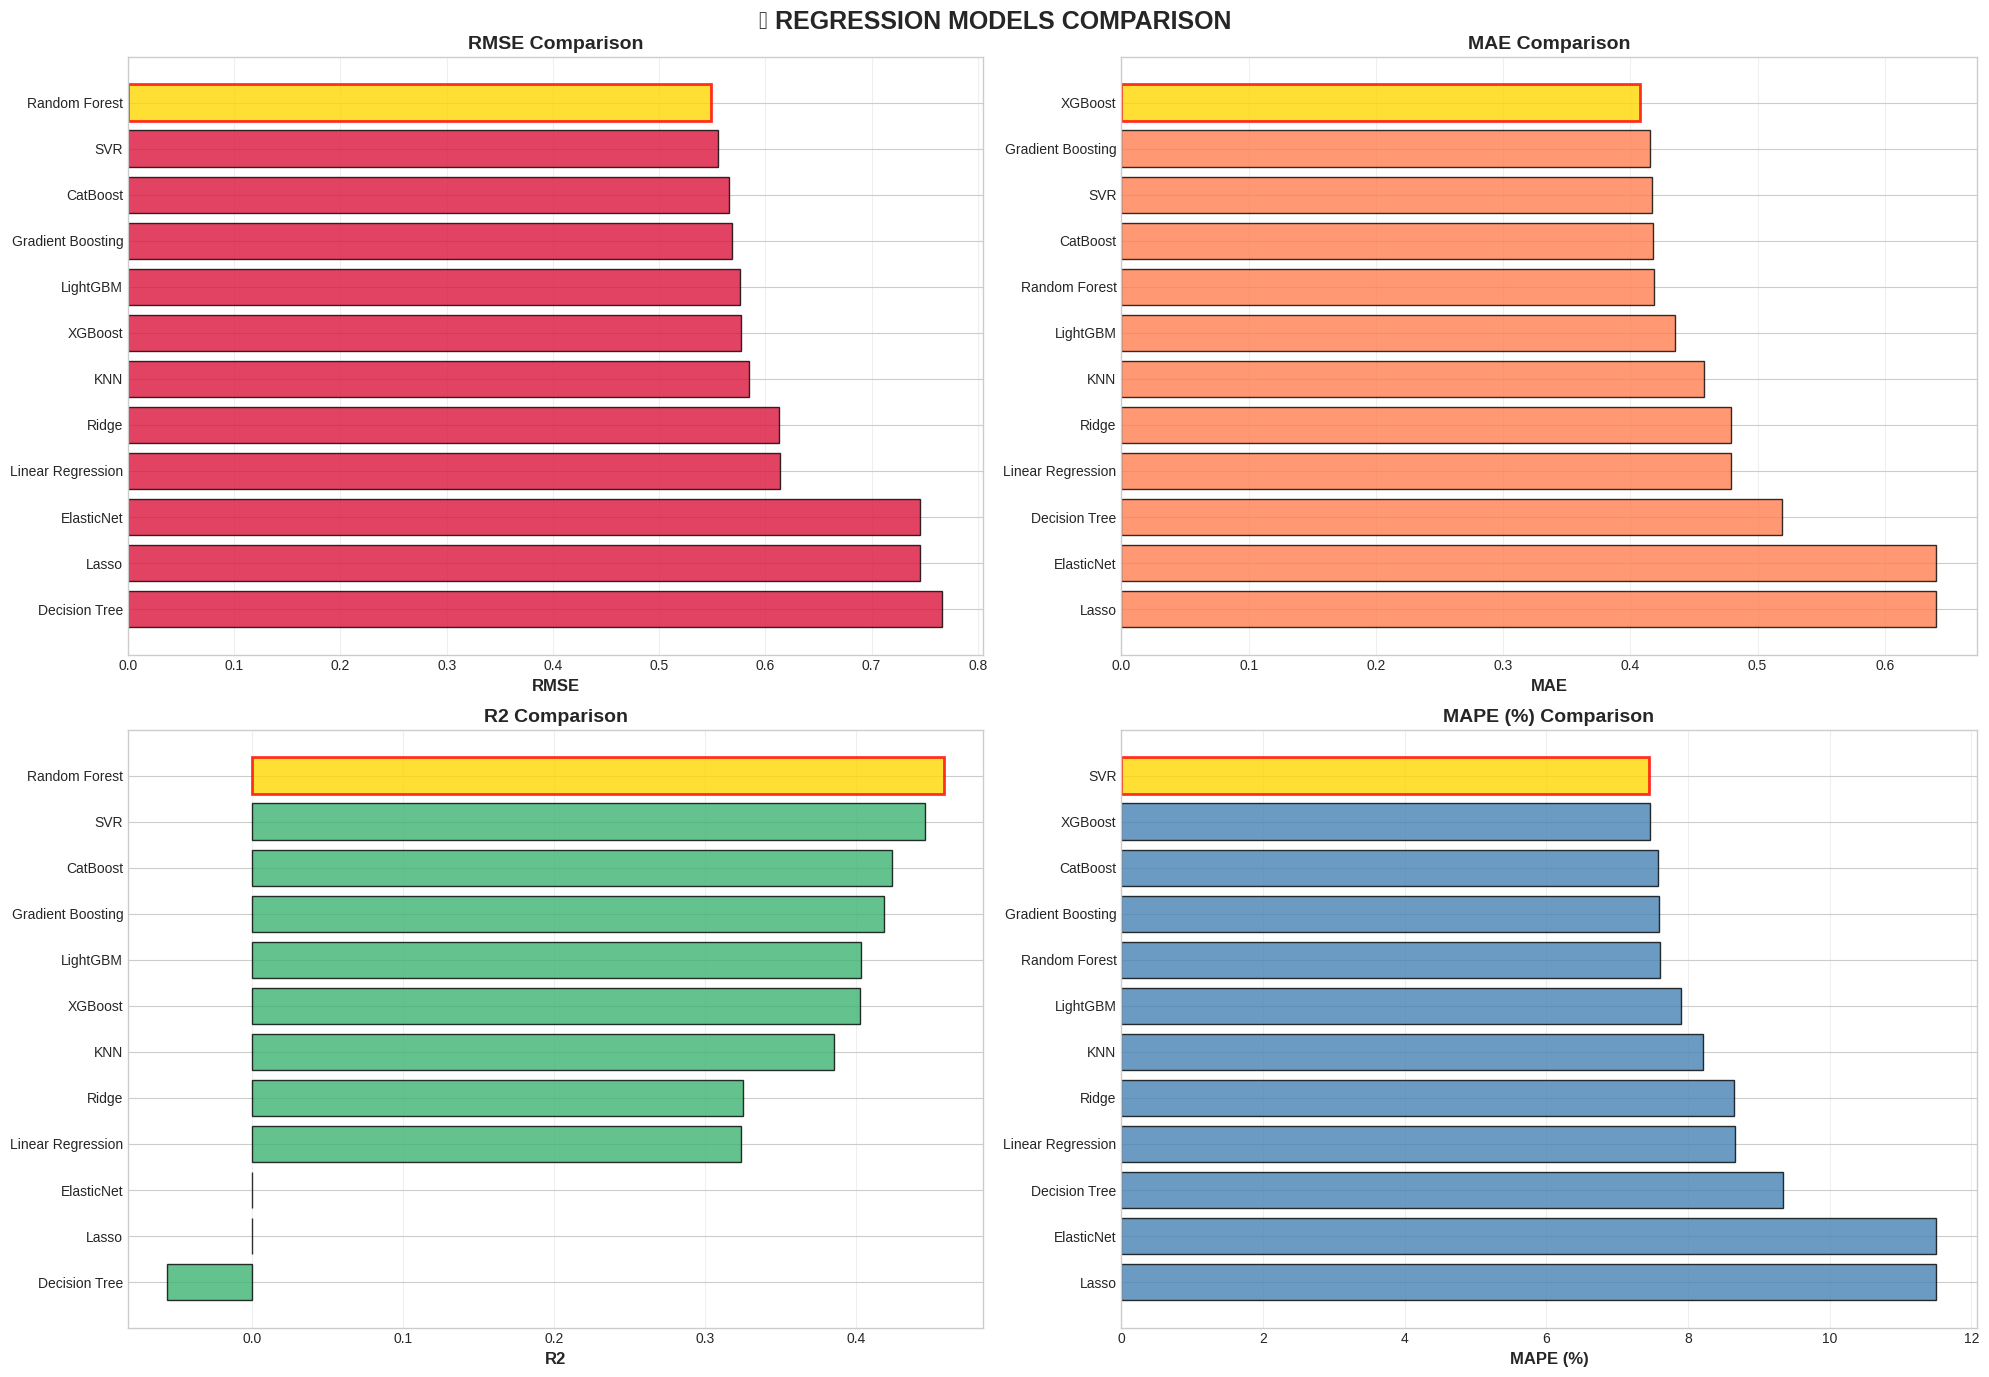

In [31]:
# Regression metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('📊 REGRESSION MODELS COMPARISON', fontsize=18, fontweight='bold')

metrics_reg = ['RMSE', 'MAE', 'R2', 'MAPE (%)']
colors = ['crimson', 'coral', 'mediumseagreen', 'steelblue']

for idx, (metric, color) in enumerate(zip(metrics_reg, colors)):
    ax = axes[idx // 2, idx % 2]

    # R2 icin buyukten kucuge, digerleri icin kucukten buyuge
    if metric == 'R2':
        sorted_df = reg_df.sort_values(metric, ascending=True)
    else:
        sorted_df = reg_df.sort_values(metric, ascending=False)

    ax.barh(sorted_df['Model'], sorted_df[metric],
           color=color, edgecolor='black', alpha=0.8)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # En iyi modeli vurgula
    if metric == 'R2':
        best_idx = sorted_df[metric].idxmax()
    else:
        best_idx = sorted_df[metric].idxmin()
    ax.get_children()[list(sorted_df.index).index(best_idx)].set_color('gold')
    ax.get_children()[list(sorted_df.index).index(best_idx)].set_edgecolor('red')
    ax.get_children()[list(sorted_df.index).index(best_idx)].set_linewidth(2)

plt.tight_layout()
plt.show()

### 📊 Visual Comparison - Part 2 (Classification Metrics)

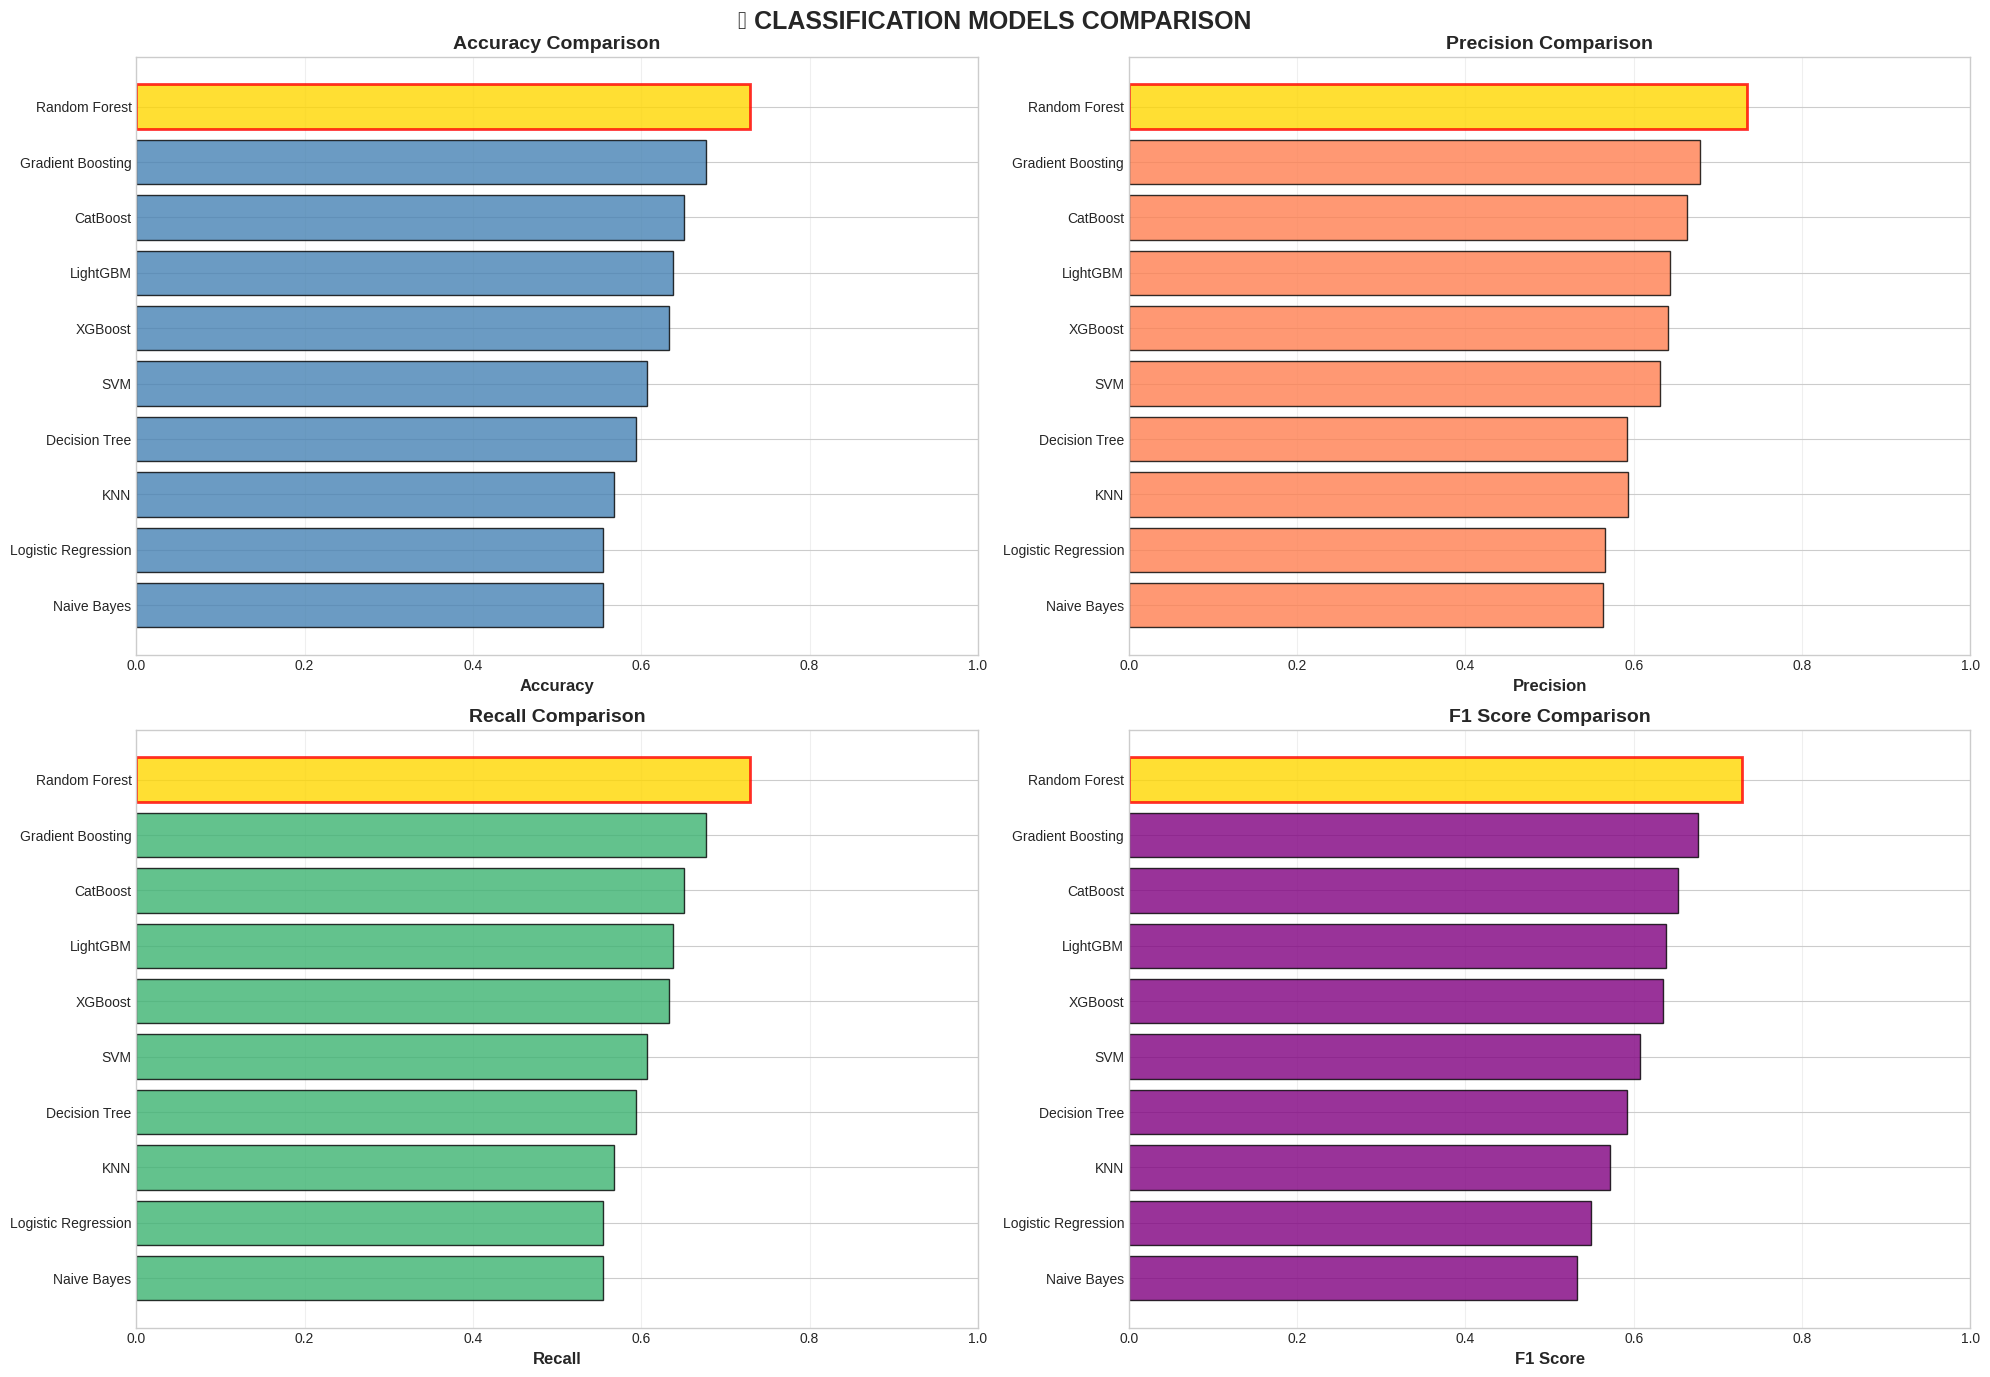

In [32]:
# Classification metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('📊 CLASSIFICATION MODELS COMPARISON', fontsize=18, fontweight='bold')

metrics_clf = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']

for idx, (metric, color) in enumerate(zip(metrics_clf, colors)):
    ax = axes[idx // 2, idx % 2]
    ax.barh(clf_df['Model'], clf_df[metric],
           color=color, edgecolor='black', alpha=0.8)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

    # En iyi modeli vurgula
    max_idx = clf_df[metric].idxmax()
    ax.get_children()[max_idx].set_color('gold')
    ax.get_children()[max_idx].set_edgecolor('red')
    ax.get_children()[max_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

### 📊 Visual Comparison - Part 3 (Confusion Matrices)

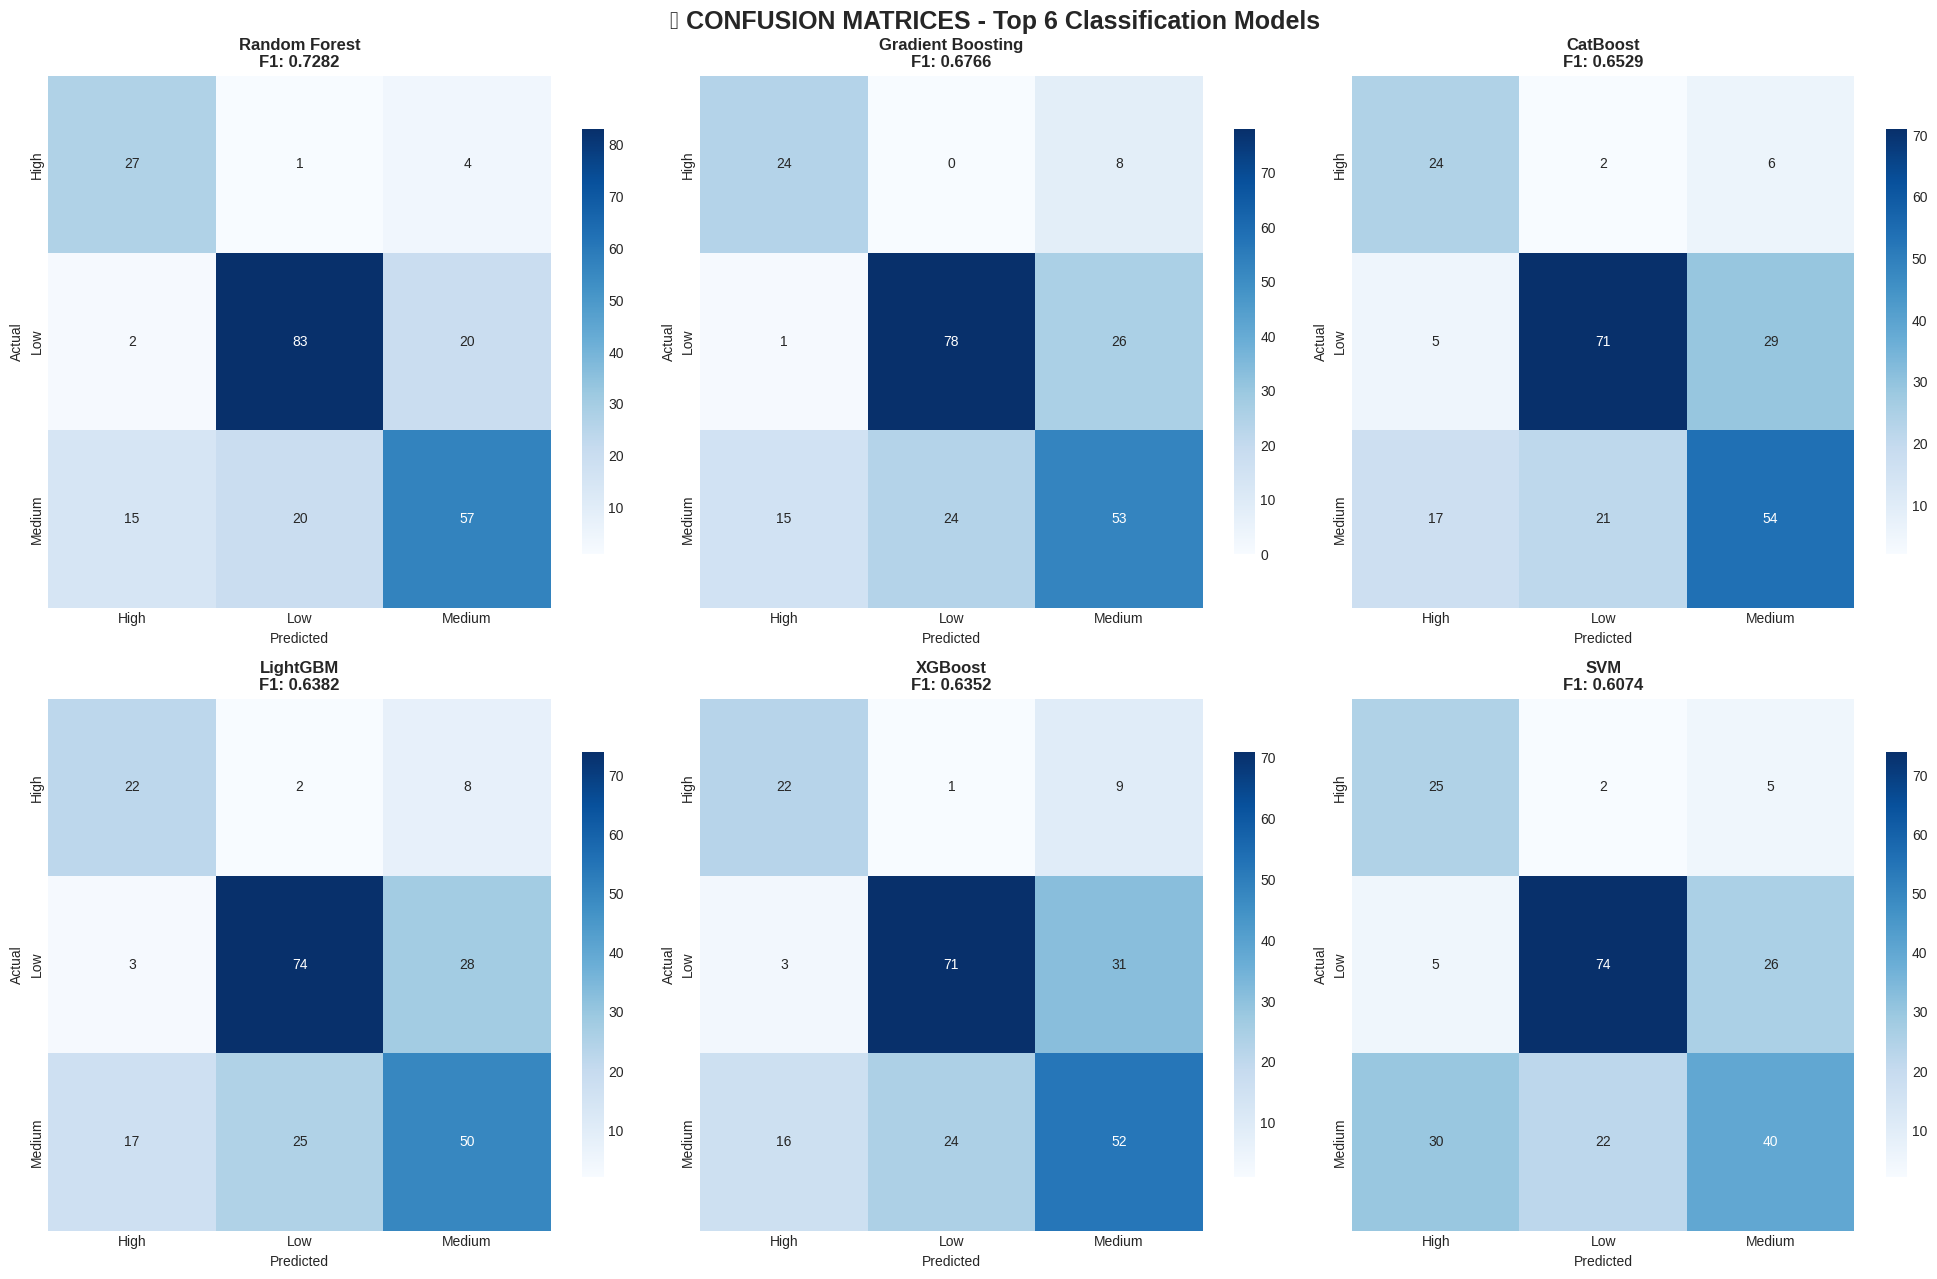

In [33]:
# Top 6 classification models confusion matrices
top_6_clf = clf_df.head(6)['Model'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('🎯 CONFUSION MATRICES - Top 6 Classification Models',
            fontsize=18, fontweight='bold')

for idx, model_name in enumerate(top_6_clf):
    ax = axes[idx // 3, idx % 3]
    cm = clf_results[model_name]['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=le_y.classes_,
               yticklabels=le_y.classes_,
               cbar_kws={'shrink': 0.8})

    ax.set_title(f'{model_name}\nF1: {clf_results[model_name]["F1_Score"]:.4f}',
                fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 📊 Visual Comparison - Part 4 (Predicted vs Actual)

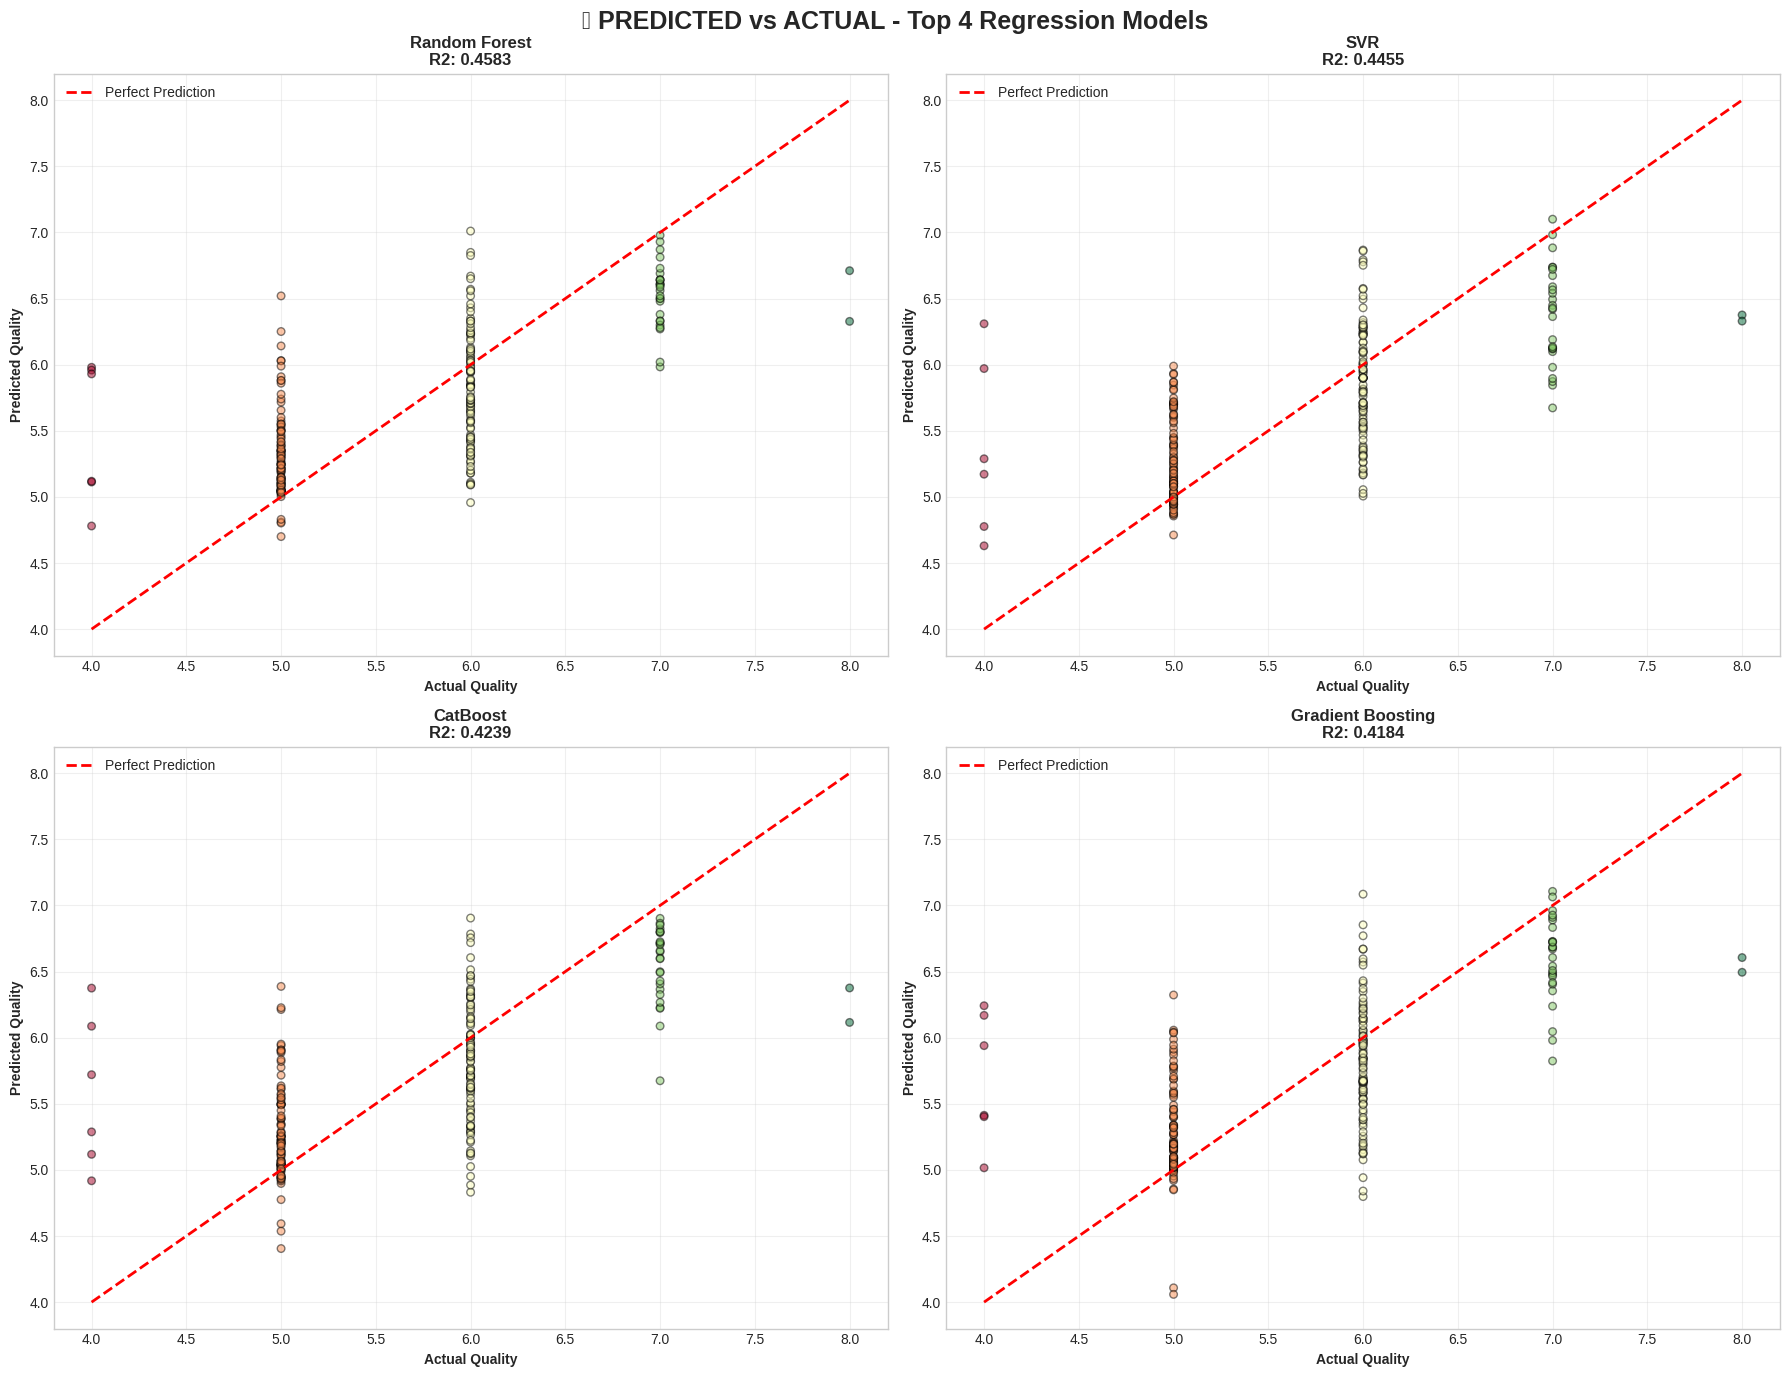

In [34]:
# Top 4 regression models - Predicted vs Actual
top_4_reg = reg_df.head(4)['Model'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('📈 PREDICTED vs ACTUAL - Top 4 Regression Models',
            fontsize=18, fontweight='bold')

for idx, model_name in enumerate(top_4_reg):
    ax = axes[idx // 2, idx % 2]

    y_pred = reg_results[model_name]['predictions']

    ax.scatter(y_test_reg, y_pred, alpha=0.5, s=30,
              c=y_test_reg, cmap='RdYlGn', edgecolor='black')
    ax.plot([y_test_reg.min(), y_test_reg.max()],
           [y_test_reg.min(), y_test_reg.max()],
           'r--', linewidth=2, label='Perfect Prediction')

    ax.set_xlabel('Actual Quality', fontweight='bold')
    ax.set_ylabel('Predicted Quality', fontweight='bold')
    ax.set_title(f'{model_name}\nR2: {reg_results[model_name]["R2"]:.4f}',
                fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Visual Comparison - Part 5 (Model Comparison Heatmap)

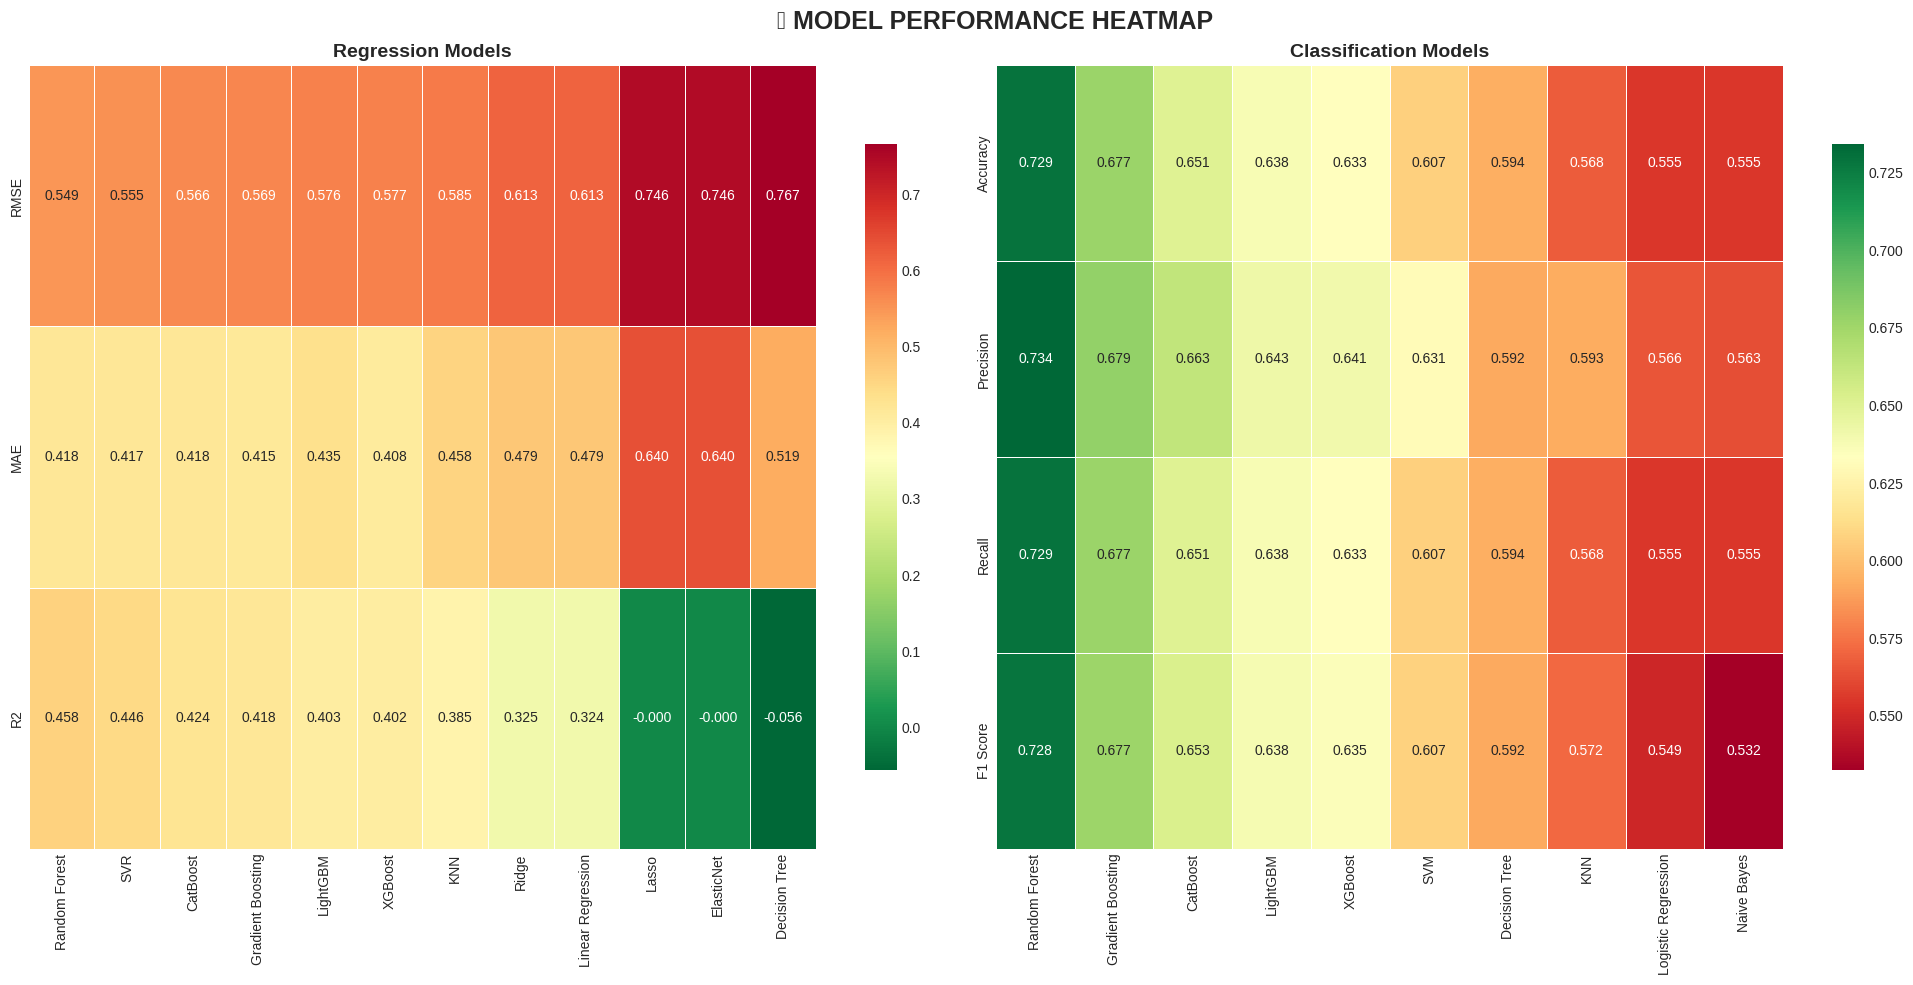

In [35]:
# Combined heatmap - All models all metrics
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('🔥 MODEL PERFORMANCE HEATMAP', fontsize=18, fontweight='bold')

# Regression heatmap
reg_heatmap = reg_df[['Model', 'RMSE', 'MAE', 'R2']].set_index('Model')
sns.heatmap(reg_heatmap.T, annot=True, fmt='.3f', cmap='RdYlGn_r',
           linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Regression Models', fontweight='bold', fontsize=14)
axes[0].set_xlabel('')

# Classification heatmap
clf_heatmap = clf_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']].set_index('Model')
sns.heatmap(clf_heatmap.T, annot=True, fmt='.3f', cmap='RdYlGn',
           linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Classification Models', fontweight='bold', fontsize=14)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 8️⃣ FINAL RESULTS & WINE EXPERT INSIGHTS

In [36]:
print('\n' + '='*100)
print('🍷 FINAL RESULTS - WINE QUALITY PREDICTION')
print('='*100)

print(f'\n📊 1. DATASET:')
print(f'   Toplam Kayit: {len(df):,}')
print(f'   Features: {len(numeric_cols)}')
print(f'   Quality Range: {df[quality_col].min():.0f} - {df[quality_col].max():.0f}')
print(f'   Average Quality: {df[quality_col].mean():.2f}')

print(f'\n🏆 2. BEST MODELS:')
print(f'   REGRESSION: {best_reg_model}')
print(f'     R2: {reg_df.iloc[0]["R2"]:.4f}')
print(f'     RMSE: {reg_df.iloc[0]["RMSE"]:.4f}')
print(f'   CLASSIFICATION: {best_clf_model}')
print(f'     F1 Score: {clf_df.iloc[0]["F1 Score"]:.4f}')
print(f'     Accuracy: {clf_df.iloc[0]["Accuracy"]:.4f}')

print(f'\n📈 3. TOP FEATURES (Quality Correlation):')
if quality_col in corr.columns:
    top_corr = corr[quality_col].abs().sort_values(ascending=False)[1:6]
    for i, (feat, val) in enumerate(top_corr.items(), 1):
        print(f'   {i}. {feat}: {val:.3f}')

print(f'\n🍷 4. WINE INSIGHTS:')
print(f'   - Alcohol content onemli kalite faktoru')
print(f'   - pH dengesi kritik')
print(f'   - Sulfur seviyeleri koruyucu rol')
print(f'   - Acidity balance lezzeti etkiler')
print(f'   - Quality genelde 5-7 arasinda yogunlasiyor')

print(f'\n📊 5. MODEL COMPARISON:')
print(f'   - {len(reg_models)} Regression Model')
print(f'   - {len(clf_models)} Classification Model')
print(f'   - 5-Part Visual Comparison')
print(f'   - 20+ EDA Visualizations')

print(f'\n🎯 6. RECOMMENDATIONS:')
print(f'   - Regression approach daha hassas tahminler icin')
print(f'   - Classification approach kategorik karar icin')
print(f'   - Feature engineering ile performans artabilir')
print(f'   - Ensemble methods denenmeli')

print('\n' + '='*100)
print('✅ WINE QUALITY PREDICTION PROJECT COMPLETED!')
print('='*100)


🍷 FINAL RESULTS - WINE QUALITY PREDICTION

📊 1. DATASET:
   Toplam Kayit: 1,143
   Features: 12
   Quality Range: 3 - 8
   Average Quality: 5.66

🏆 2. BEST MODELS:
   REGRESSION: Random Forest
     R2: 0.4583
     RMSE: 0.5490
   CLASSIFICATION: Random Forest
     F1 Score: 0.7282
     Accuracy: 0.7293

📈 3. TOP FEATURES (Quality Correlation):
   1. alcohol: 0.485
   2. volatile acidity: 0.407
   3. sulphates: 0.258
   4. citric acid: 0.241
   5. total sulfur dioxide: 0.183

🍷 4. WINE INSIGHTS:
   - Alcohol content onemli kalite faktoru
   - pH dengesi kritik
   - Sulfur seviyeleri koruyucu rol
   - Acidity balance lezzeti etkiler
   - Quality genelde 5-7 arasinda yogunlasiyor

📊 5. MODEL COMPARISON:
   - 12 Regression Model
   - 10 Classification Model
   - 5-Part Visual Comparison
   - 20+ EDA Visualizations

🎯 6. RECOMMENDATIONS:
   - Regression approach daha hassas tahminler icin
   - Classification approach kategorik karar icin
   - Feature engineering ile performans artabilir
  